<img src="https://datamasters.it/cdn-cgi/image/w=3072,h=1728,f=jpeg,fit=cover/https://website-prod.datamasters.it/wp-content/uploads/2024/08/Cover-blog-post-rebranding.jpg" alt="Data Masters" width=500/></a>

# Fine-Tuning di Large Language Model su Budget Limitato
<br/><br/>
**Mini-guida pratica al fine-tuning**

Insegnare a **Gemma 4 E2B** (5.1B params, Apache 2.0) il canone interno della *Pizza del Programmatore* via **QLoRA** su Colab T4 free. Stack puro `transformers + peft + trl`, con un'integrazione finale in `langchain-huggingface`.

Il notebook è **autosufficiente**: il dataset Q/A è embedded nella cella dedicata, non servono file esterni né credenziali. Il modello base Gemma è scaricabile senza token (license Apache 2.0).

**Speaker**:<br/>Vincenzo Maritati (Data Masters)

## §0 - Postulati

Cinque affermazioni dichiarate prima di leggere il codice. Le ribadirò lungo il notebook. Se ne contesti almeno una, leggi con scetticismo costruttivo - è il modo giusto.

> **P1.** Il fine-tuning non è la prima scelta. È la **terza**, dopo prompting e RAG. Si arriva qui solo quando le prime due falliscono per ragioni motivate, non per pigrizia di pensiero.

> **P2.** LoRA non è "il fine-tuning per chi non ha le GPU". È **il fine-tuning di prima scelta** per molti casi domain-specific. Il full fine-tune in 2026 è spesso uno spreco di compute e VRAM su domini ristretti (opinione editoriale del notebook).

> **P3.** Un dataset da poche decine di esempi può bastare, **se** la diversità degli intent è alta. Diversità batte volume su dataset piccoli. La doc ufficiale Gemma è esplicita: *"one input can have multiple correct outputs"* - la varianza confonde, la coerenza insegna.

> **P4.** Training/inference parity è un'invariante non negoziabile. Stesso `system message`, stessa formattazione chat, stesso processor. Mismatch = degradation silenziosa = settimane perse a debuggare.

> **P5.** I tutorial pre-2026 sono **rotti** su Gemma 4. Multimodalità → `AutoProcessor`, non `AutoTokenizer`. Wrapper `Gemma4ClippableLinear` → suffisso `.linear` nei `target_modules`. VLM classification in TRL → `assistant_only_loss=False`. Sapere queste tre cose risparmia ~4h di stack-overflow.

### Mappa teorica della guida

Prima di tuffarci nel codice, una mappa: questa esercitazione attraversa 5 territori tecnici. Ogni cella di codice è anche un pezzo di uno di questi territori. Teniamoli a mente e alla fine del notebook avremo una mini-guida di riferimento sul fine-tuning di LLM su hardware limitato.

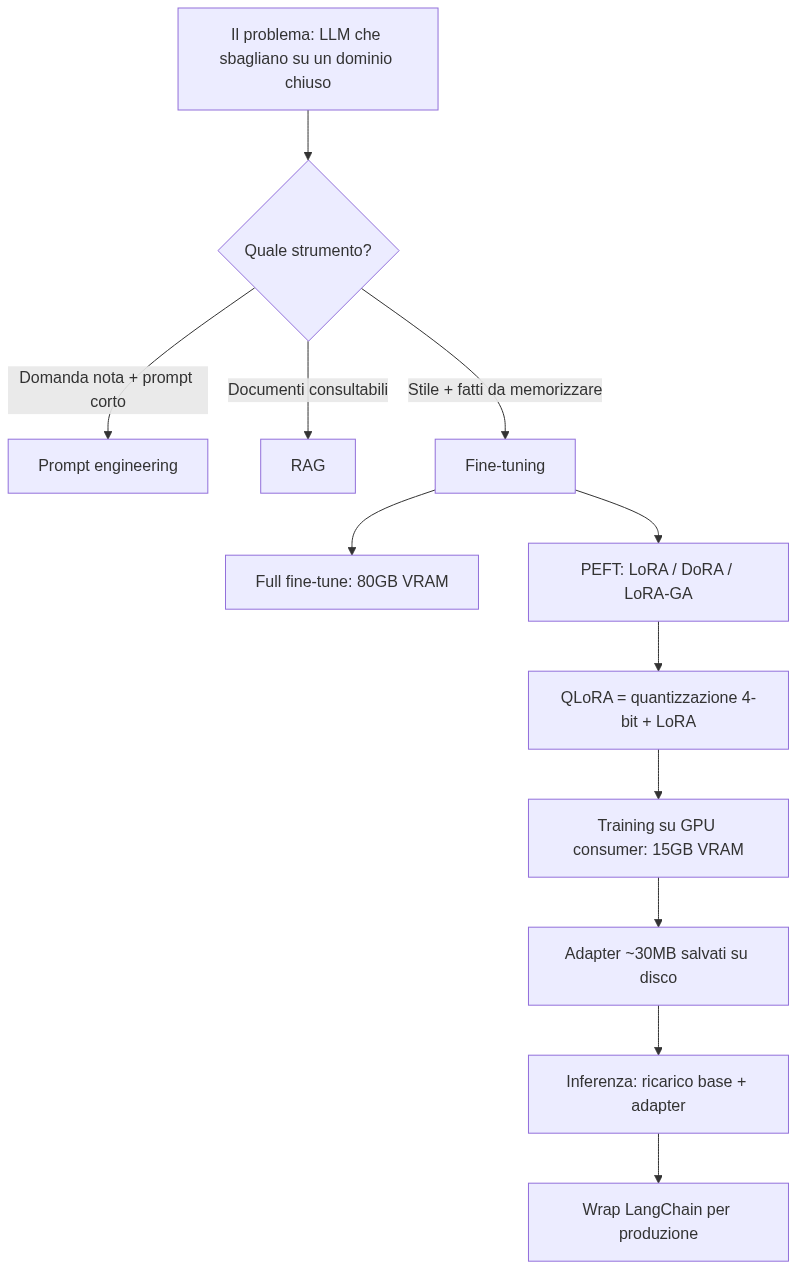

<details><summary> Codice sorgente del diagramma (Mermaid)</summary>

```mermaid
flowchart TD
 A[Il problema: LLM che sbagliano su un dominio chiuso] --> B{Quale strumento?}
 B -->|Domanda notiamo + prompt corto| C[Prompt engineering]
 B -->|Documenti consultabili| D[RAG]
 B -->|Stile + fatti da memorizzare| E[Fine-tuning]
 E --> F[Full fine-tune: 80GB VRAM]
 E --> G[PEFT: LoRA / DoRA / LoRA-GA]
 G --> H[QLoRA = quantizzazione 4-bit + LoRA]
 H --> I[Training su GPU consumer: 15GB VRAM]
 I --> J[Adapter ~48MB salvati su disco]
 J --> K[Inferenza: ricarico base + adapter]
 K --> L[Wrap LangChain per produzione]
```

</details>

**Cosa esploreremo, in mappa**:

1. **Diagnosi**: perché prompt engineering e RAG non risolvono il caso *dominio chiuso + stile distintivo*. Sezione 1-2.
2. **Quantizzazione (NF4 4-bit) + LoRA**: come si carichiamo un modello da 5.1B parametri in 6GB di VRAM. Sezione 3.
3. **Dataset & chat template**: i token speciali del template Gemma 4, perché training/inference parity è critica. Sezione 4.
4. **PEFT in pratica**: matematica di LoRA, scelta dei `target_modules`, configurazione di `SFTTrainer`. Sezione 5.
5. **Validazione + deployment**: sanity check post-training, formati di condivisione, wrapping in LangChain. Sezioni 6-7.

<br/><br/>
_______
<br/><br/>
**Glossario lampo** (li espandiamo quando li incontriamo nel testo):

| Sigla | Significato |
|---|---|
| **LLM** | Large Language Model |
| **PEFT** | Parameter-Efficient Fine-Tuning |
| **LoRA** | Low-Rank Adaptation (Hu et al. 2021) |
| **QLoRA** | Quantized LoRA: NF4 + LoRA (Dettmers et al. 2023) |
| **DoRA** | Weight-Decomposed LoRA (Liu et al. 2024, NVIDIA, ICML Oral) |
| **NF4** | NormalFloat 4-bit - formato 4-bit ottimizzato per pesi distribuiti normalmente |
| **SFT** | Supervised Fine-Tuning |
| **VLM** | Vision-Language Model (modello multimodale) |
| **OOM** | Out Of Memory - la GPU finisce la VRAM |


## §1 - Diagnosi: il modello base inventa il canone

**Setup mentale**: abbiamo un dominio chiuso di poche fattiinformazioni interne che il modello base non ha visto in pre-training. Chiediamo a Gemma 4 base degli ingredienti della Pizza del Programmatore e verifichiamo come fallisce e perché.

Il punto della §1 non è "wow, è confidente e sbagliato" ma è **separare tre fallimenti di stack** che spesso vengono confusi tra loro:

- **Stile** (apertura `Aloha!`, ordine canonico ingredienti) - risolvibile con prompting o few-shot
- **Canone fattuale** (esattamente quali ingredienti, in che ordine) - qui prompting/RAG hanno limiti reali
- **Distinzione tra varianti** (Pizza del Programmatore rossa vs Pizza Programmatora bianca) - questo è dove il fine-tuning vince per davvero.

### Le 8 tipologie di LLM e dove sta Gemma 4

Prima di scegliere come comprimere un modello, va capito *cosa* abbiamo davanti. Otto categorie principali al 2026:

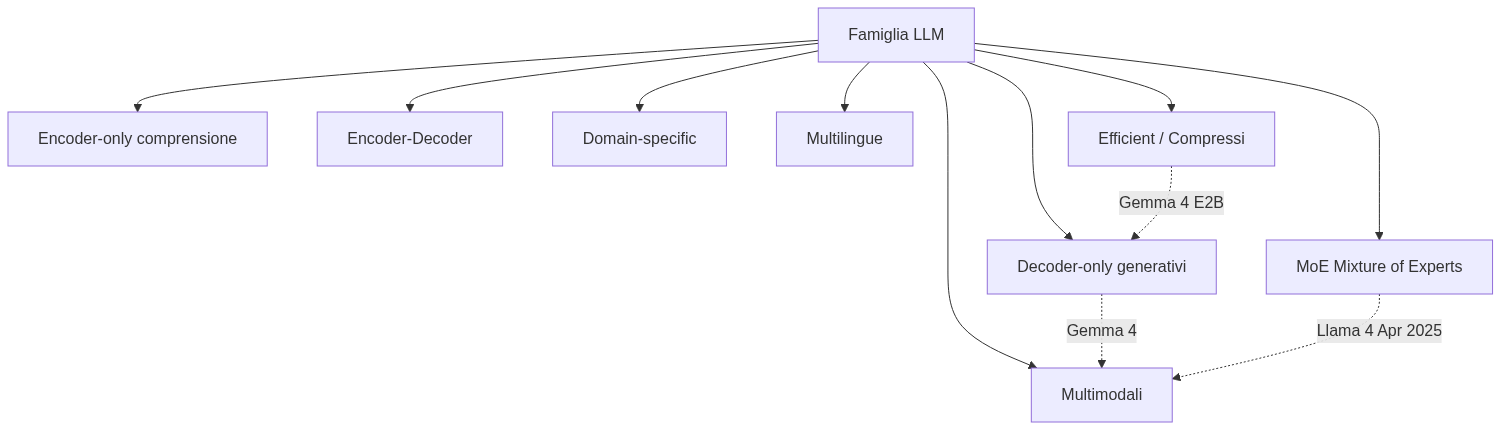

<details><summary> Codice sorgente del diagramma (Mermaid)</summary>

```mermaid
flowchart TD
 LLM[Famiglia LLM] --> DEC[Decoder-only generativi]
 LLM --> ENC[Encoder-only comprensione]
 LLM --> ED[Encoder-Decoder]
 LLM --> MM[Multimodali]
 LLM --> DOM[Domain-specific]
 LLM --> ML[Multilingue]
 LLM --> EFF[Efficient / Compressi]
 LLM --> MOE[MoE Mixture of Experts]
 DEC -.->|Gemma 4| MM
 EFF -.->|Gemma 4 E2B| DEC
 MOE -.->|Llama 4 Apr 2025| MM
```

</details>

| Tipologia | Cosa fa | Esempi 2025-2026 |
|---|---|---|
| **Decoder-only generativi** | Generano token-by-token, usati per chat/completamento | Gemma 4, GPT-4o, Claude family |
| **Encoder-only** | Comprensione (classificazione, sentiment, embedding) | BERT, RoBERTa, ModernBERT |
| **Encoder-Decoder** | Comprensione + generazione (traduzione, riassunto) | T5, FLAN-T5, mT5 |
| **Multimodali** | Testo + immagini + audio (+ video) unificati | Gemma 4 (text+image+audio), Llama 4, GPT-4o |
| **Domain-specific** | Pre-addestrati su corpora settoriali | BioGPT, Med-PaLM, CodeLlama |
| **Multilingue** | Nativamente N lingue | XLM-R, BLOOM, Mistral Large |
| **Efficient / Compressi** | Per edge / on-device | Phi-3-mini, Gemma 4 E2B, DistilGPT |
| **MoE (Mixture of Experts)** | Attivano solo N esperti per token | Mixtral 8x7B, Llama 4 (128 experts), DeepSeek-V3 |

**Dove sta Gemma 4 E2B**: decoder-only + multimodale + efficient. I 5.1B parametri totali diventano **2.3B effettivi nel forward** grazie al **PLE** (Parameter-Layer Embedding sharing): embedding di input e `lm_head` condividono la stessa matrice di pesi (256000 × 2304). Nel nostro caso lavoriamo solo testo, ma sotto il cofano resta multimodale.

###  Le 6 famiglie di compressione (e come si combinano)

LoRA non è una tecnica isolata: appartiene a una famiglia più grande. Le sei famiglie principali:

| Famiglia | Cosa modifichiamo | Impatto qualità | Quando usarla |
|---|---|---|---|
| **Quantizzazione** | Precisione numerica (16-bit → 4/8-bit) | Minima se ben fatta (NF4, AWQ); significativa con int4 naive | Inferenza, training (in QLoRA) |
| **Distillazione** | Trasferisce conoscenza da teacher grande a student piccolo | Minima (es. DistilBERT: -40% size, -3% qualità) | Quando possiamo permetterti pre-training |
| **Pruning** | Rimuove pesi/neuroni a basso impatto | Significativo se >50% pruning | Inferenza, deployment edge |
| **LoRA / DoRA / LoRA-GA** | Aggiunge matrici a basso rango invece di toccare i pesi originali | Minima se r adeguato | Fine-tuning efficiente |
| **Sparse Training** | Vincoli di sparsità durante il training | Dipende dal livello | Training + inferenza |
| **Tensor Decomposition** | Fattorizza tensori (SVD, CP, Tucker) | Dipende dalla decomposizione | Compressione convnet o NLP |

> **Le tecniche si combinano**: QLoRA = quantizzazione (4-bit NF4) + LoRA. Distillazione + quantizzazione = molti modelli edge moderni. È raro che una sola tecnica basti a portare un modello su hardware modesto.

### Le 3 famiglie di quantizzazione 4-bit moderne (chi fa cosa)

Tre formati 4-bit ricorrono nei tutorial: **NF4**, **AWQ**, **GPTQ**. Servono a scopi diversi.

| Formato | Quando viene applicato | Hardware ottimale | Use case |
|---|---|---|---|
| **NF4** (4-bit NormalFloat, BitsandBytes) | **A load-time**, on-the-fly: prendiamo un modello fp16 e lo quantizzi al caricamento | GPU NVIDIA con `bitsandbytes` | **Training in QLoRA**: è il nostro caso |
| **AWQ** (Activation-aware Weight Quantization) | Pre-quantizzato offline, salvato come modello AWQ | Edge GPU (TensorRT, Marlin-AWQ ~741 tok/s su A10G) | Inferenza ad alte performance |
| **GPTQ** (Generative Pre-trained Transformer Quantization) | Pre-quantizzato offline, calibrazione layer-wise | GPU generici, ecosistema maturo | Inferenza, ampia disponibilità di modelli pre-quantizzati |

> **Regola pratica**: NF4 per fare il training (è quello che il nostro notebook usiamo), AWQ/GPTQ per servire il modello in produzione. AWQ è competitivo sui benchmark recenti per qualità e velocità (la classifica varia per modello e task; verificare per il proprio caso d'uso); GPTQ resta lo standard de-facto per disponibilità di modelli pre-quantizzati su HF Hub.

## §2 - Decisione: FT vs RAG vs prompting

Tre strumenti, tre superpoteri diversi, tre fallimenti diversi.<br/>
La tabella sotto è la mia heuristica personale dopo aver sbattuto la testa abbastanza volte da farla diventare una checklist.

### Tabella decisionale

| Asse | Prompting | RAG | Fine-tuning |
|---|---|---|---|
| Cambia *cosa* | input | contesto recuperato | pesi |
| Costo per query | basso | medio | gratis dopo il training |
| Costo upfront | 0 | medio (vector store) | alto (training) |
| Conoscenza dinamica | ok | ok+ | no |
| Stile/tono persistente | parziale | no | sì |
| Latenza extra | 0 | +retrieval | 0 |
| Quando vince | 1-shot, knowledge generale | knowledge dinamica esterna | stile + canone interno chiuso |

Il caso *pizza* ricade nella terza colonna: **nuova conoscenza e stile riconoscibile** (l'apertura "Aloha!"). Il prompting va a corto di token contestuali su query lunghe; la RAG aggiunge latenza e infrastruttura per poche informazioni (la ricetta) che non cambieranno mai. Il fine-tuning colpisce nel segno.

### LoRA in un diagramma

LoRA congela la matrice di pesi `W` e impara due matrici a basso rango: `A` di forma (d × r) e `B` di forma (r × d). L'output diventa `W·x + (alpha/r) · B·A·x`. Con `r=16` su Gemma 4 alleniamo lo 0.4% dei parametri totali. **QLoRA** = LoRA con `W` quantizzata a 4-bit (formato NF4): la VRAM richiesta crolla da ~80 GB a ~6 GB e la perdita di qualità è marginale.

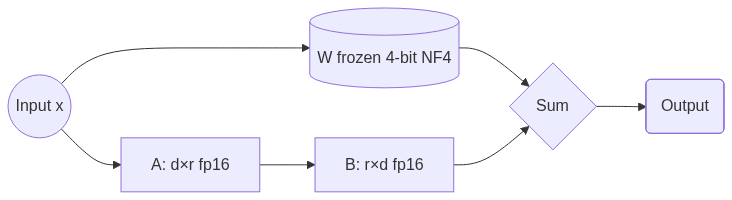

<details><summary> Codice sorgente del diagramma (Mermaid)</summary>

```mermaid
flowchart LR
 X((Input x)) --> Wfrozen[(W frozen 4-bit NF4)]
 X --> A[A: d×r fp16]
 A --> B[B: r×d fp16]
 Wfrozen --> Sum{Sum}
 B --> Sum
 Sum --> Y(Output)
```

</details>

Riferimenti: *LoRA - Hu et al. 2021* (arXiv:2106.09685), *QLoRA - Dettmers et al. 2023* (arXiv:2305.14314).

> 0.4% dei pesi, ~48 MB di adapter, modello impara. **Non è la scorciatoia di chi non ha le GPU. È la scelta tecnica di prima scelta per molti casi domain-specific.**

Sappiamo *cosa* fare. Resta il *come*: caricare un modello multimodale da 5.1B params in 6 GB su una T4 free senza farla esplodere. Apriamo Colab.

## §3 - Setup: Gemma 4 in 4-bit su T4 free

Da qui in poi è codice. Tutto il notebook gira su **Colab T4 free** (15 GB di VRAM) senza setup esterno: niente file da scaricare, niente mount Drive, niente HF token. Se la T4 non c'è (Colab a volte assegna una L4), il codice gira lo stesso ma le timing che leggi a runtime saranno diverse (è normale, non un bug).

<!-- hf-token-setup -->
### HF_TOKEN - autenticazione Hugging Face in Colab

Il download di Gemma 4 dall'Hub funziona anche senza token, ma in modalità anonima paghi due tasse: **rate limit aggressivo** (errore 429 se la stessa IP del runner Colab ha già scaricato modelli oggi) e **banda dimezzata**. Quando vediamo il warning

```
Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN
to enable higher rate limits and faster downloads.
```

stai pagando entrambe. Si risolve in tre minuti, una volta sola per account.

**Passo 1 - Crea un token su Hugging Face** (se non ne abbiamo uno):

1. Vai su [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens) (login richiesto).
2. Clicca **"Create new token"** → tab **"Read"** (NON "Fine-grained", ci complica la vita per nulla; NON "Write", non ci serve pushare).
3. Nome del token: qualcosa di parlante, es. `colab-workshop`. **Expiration**: 30 giorni va benissimo per il workshop (rotazione = igiene).
4. Clicca **"Generate a token"** e **copialo subito**: HF te lo mostra una sola volta (`hf_xxxxxxxxxxxxxxxxxxxx`).

**Passo 2 - Accetta la licenza Gemma** (gate one-shot per account):

1. Vai su [huggingface.co/google/gemma-4-E2B-it](https://huggingface.co/google/gemma-4-E2B-it).
2. In alto trovi un banner "You need to agree to share your contact information" - accetta. È una formalità Google (ti chiede nome/azienda/use-case), approvazione automatica in pochi secondi. Senza questo step il download torniamo 401 anche col token.

**Passo 3 - Aggiungi il token ai Secrets di Colab**:

1. Nel notebook Colab, **sidebar sinistra → icona chiave "Secrets"**.
2. **"+ Add new secret"**.
3. **Name**: `HF_TOKEN` (esattamente questo, in maiuscolo - è il nome che `huggingface_hub` cerca di default).
4. **Value**: incolla il token `hf_xxx...` del Passo 1.
5. Abilita lo switch **"Notebook access"** (altrimenti il notebook non lo legge, anche se è salvato).

Fatto. Il prossimo `from_pretrained("google/gemma-4-E2B-it", ...)` userà il token automaticamente - il secret viene esposto come env var dentro il runtime Colab e `huggingface_hub` lo raccoglie senza ulteriori passi.

**La prossima cella propaga automaticamente** il secret in `os.environ` (il ponte mancante che `huggingface_hub` si aspetta). Se l'output stampa `HF_TOKEN caricato dai Colab Secrets` sei a posto.

> **Privacy**: il secret è legato al nostro account Google e al singolo notebook (Notebook access scope). Non finisce nel `.ipynb` salvato su Drive, né in eventuali condivisioni del notebook. Se condividi il file, l'altra persona dovrà creare il proprio token.


In [ ]:
# hf-token-propagate
# Tre passi per autenticare il runtime Colab con Hugging Face Hub:
#  1) leggi il Colab Secret e mettilo in os.environ (rapido)
#  2) chiama huggingface_hub.login(): scrive il token in ~/.cache/huggingface/token
#     e riconfigura il client HfApi globale. Solo questo step lo rende visibile
#     a transformers, che ha gia importato huggingface_hub al momento del pip install.
#     Settare solo os.environ non basta perche il client e gia istanziato senza token.
#  3) whoami() come verifichiamo deterministica: se stampa username, sei dentro.
import os

try:
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

    from huggingface_hub import login, whoami
    login(token=os.environ["HF_TOKEN"], add_to_git_credential=False)
    user = whoami()
    print(f"HF_TOKEN attivo: autenticato come {user['name']} (download autenticato + rate limit pieno).")
except ImportError:
    print("Non sei su Colab: assicurati che HF_TOKEN sia in os.environ via altro canale.")
except Exception as e:
    # SecretNotFoundError | NotebookAccessError | 401 token errato | ecc.
    print(f"HF_TOKEN non utilizzabile ({type(e).__name__}): {e}")
    print("Procedi pure: Gemma 4 E2B-it e pubblico, download anonimo funziona ma rate-limited.")


HF_TOKEN non utilizzabile (SecretNotFoundError): Secret HF_TOKEN does not exist.
Procedi pure: Gemma 4 E2B-it e pubblico, download anonimo funziona ma rate-limited.


### Install delle librerie con versioni fissate

Per "fissare" una versione (in inglese *to pin a version*) si intende dichiarare nel comando `pip install` un intervallo di versioni accettabili, per esempio `transformers>=5.5.0,<5.8.0`. Questo significa "voglio una qualunque versione che sia almeno la 5.5.0 e strettamente inferiore alla 5.8.0".

Perché lo facciamo: senza versioni fissate, ogni nuovo run del notebook potrebbe installare una release più recente con una API leggermente diversa (in gergo *API drift*), e il codice che ieri girava oggi rompe in modo non riproducibile. Qui usiamo intervalli stretti sul *major* / *minor* (cambi che possono rompere il codice) e larghi sul *patch* (bugfix).

Installiamo qui tutte le dipendenze del notebook, **inclusi i pacchetti LangChain** che useremo nella sezione 7. Centralizzare l'install evita doppi `pip install` e riduce il rischio di conflitti di dipendenze risolti diversamente in due fasi.

Cosa ci serve da ciascun pacchetto:

- `transformers>=5.5.0` introduce Gemma 4 nativo (`AutoProcessor`).
- `trl>=1.1.0` riconosce i marker `{% generation %}` nel template Jinja di Gemma 4. *Jinja* è un linguaggio di template testuale (segnaposto `{{ var }}` per variabili, blocchi `{% if %}` / `{% for %}` per logica) - il chat template del tokenizer è un file Jinja che genera la stringa formattata a partire dalla lista di `messages`.
- `peft>=0.19.0` aggiunge `ensure_weight_tying=True`. Tradotto: in Gemma il layer di embedding (che traduce token → vettori) e l'`lm_head` (che traduce vettori → logit dei token) **condividono la stessa matrice di pesi**. PEFT 0.19+ gestisce correttamente questa condivisione, le versioni precedenti no.
- `bitsandbytes>=0.45.4` è stabile sulla T4 (architettura Turing, SM 7.5).
- `langchain-huggingface>=0.1.2` + `langchain-core>=0.3.0` per la sezione 7 (wrapping del modello fine-tunato in una chain).

L'install dura circa 60-120 secondi su Colab T4 free; stampiamo il tempo effettivo a fine cella.

In [ ]:
import time
_t0 = time.time()

!pip install -q -U \
 "transformers>=5.5.0,<5.8.0" \
 "peft>=0.19.0,<0.20.0" \
 "trl>=1.1.0,<1.4.0" \
 "bitsandbytes>=0.45.4" \
 "accelerate>=1.2.0" \
 "datasets>=3.2.0" \
 "langchain-huggingface>=0.1.2" \
 "langchain-core>=0.3.0"

print(f"\n Install librerie completato in {time.time() - _t0:.0f}s")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 16.6 MB/s eta 0:00:00

 Install librerie completato in 45s


### Import centralizzati + seed di riproducibilità

Tutti gli import del notebook in **un'unica cella**: dà una visione d'insieme delle dipendenze, evita che ogni sezione ripeta le stesse `from ... import ...` e rende ovvio cosa cambiare se si vuole sostituire un pacchetto.

`set_seed(42)` di `transformers` imposta in un colpo solo il seed di `random`, `numpy`, `torch` (CPU e CUDA). Senza questo, su un dataset piccolo come il nostro la varianza run-to-run è alta: la loss finale può oscillare di ±0.3 a parità di config, e ogni partecipante vede risposte leggermente diverse. Con il seed fissato a 42 lo stesso notebook produce gli stessi numeri due esecuzioni di fila.

In [ ]:
# Riduce frammentazione VRAM sulla T4 (raccomandato da PyTorch per modelli
# grandi al limite della memoria GPU). Va settato PRIMA di import torch.
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# --- stdlib ---
import time
import importlib.metadata as md
from collections import Counter
from pathlib import Path

# --- scientific / plotting ---
import torch
import matplotlib.pyplot as plt

# --- Hugging Face ecosystem ---
from datasets import Dataset
from transformers import (
    set_seed,
    AutoProcessor,
    AutoModelForImageTextToText,
    BitsAndBytesConfig,
    pipeline,
)
from peft import LoraConfig, get_peft_model
from trl import SFTConfig, SFTTrainer

# --- LangChain (sezione 7) ---
from langchain_huggingface import HuggingFacePipeline, ChatHuggingFace
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Seed unico per random, numpy, torch CPU+CUDA - rende deterministici:
# data shuffling, init pesi LoRA, sampling di generazione (quando do_sample=True).
set_seed(42)

### Pre-flight check

Una cella che fallisce *forte e in fretta* se manca qualcosa. Meglio scoprire ora che siamo per errore su CPU, piuttosto che dopo cinque minuti di download del modello. Visualizziamo anche le versioni installate dei pacchetti chiave: utile per riprodurre il setup o per diagnosticare differenze quando il notebook gira su ambienti diversi.

>  Colab assegna una GPU di tipo T4 nella maggior parte degli slot free, ma a volte può capitarti una L4 (più potente, ma diversa). La libreria `bitsandbytes` che useremo per la quantizzazione a 4-bit è compilata per architetture GPU specifiche, e le versioni dei pacchetti che funzionano sulla T4 (Turing, SM 7.5) possono non essere quelle ottimali sulla L4 (Ada Lovelace, SM 8.9). In altre parole: gli intervalli di versione che abbiamo dichiarato nella cella precedente sono pensati per T4. Se Colab ti assegna una L4, è probabile che il notebook giri lo stesso, ma se vediamo errori strani di `bitsandbytes` la prima ipotesi è "non sono sulla T4 attesa".

In [ ]:
assert torch.cuda.is_available(), (
    "GPU non disponibile. Vai su Runtime -> Cambia tipo di runtime -> T4 GPU."
)

gpu_name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU rilevata: {gpu_name}")
print(f"VRAM totale:  {vram_gb:.1f} GB")

print("\nVersioni installate:")
for pkg in ["transformers", "peft", "trl", "bitsandbytes", "accelerate",
            "datasets", "langchain-huggingface", "langchain-core"]:
    print(f"  - {pkg}: {md.version(pkg)}")

GPU rilevata: Tesla T4
VRAM totale:  15.6 GB

Versioni installate:
  - transformers: 5.7.0
  - peft: 0.19.1
  - trl: 1.3.0
  - bitsandbytes: 0.49.2
  - accelerate: 1.13.0
  - datasets: 4.8.5
  - langchain-huggingface: 1.2.2
  - langchain-core: 1.4.0


**Checkpoint pre-flight**: se non vediamo una GPU, fermati qui. Non è un errore del notebook: dobbiamo cambiare runtime su Google Colab.

### Load Gemma 4 E2B in 4-bit (QLoRA-ready)

La configurazione di `BitsAndBytesConfig`:

- **`load_in_4bit=True`** attiva la quantizzazione a 4-bit dei pesi del modello base.
- **`bnb_4bit_quant_type="nf4"`** sceglie il formato *NormalFloat 4-bit* (paper QLoRA): batte int4 simmetrico sulle distribuzioni gaussiane tipiche dei pesi.
- **`bnb_4bit_use_double_quant=True`** quantizza anche le costanti di quantizzazione: risparmia circa 0.4 bit per parametro.
- **`bnb_4bit_compute_dtype=torch.float16`** è obbligatorio sulla T4 (Turing SM 7.5): non supporta bf16.

Curiosità: Gemma 4 E2B ha 5.1B params *contando gli embedding*, ma 2.3B *effettivi* nel forward (35 layer densi). In 4-bit NF4 + double quant: ~3 GB di pesi + ~3 GB di activation buffer = ~6 GB totali. Sotto la soglia 8 GB target di questa esercitazione.

In [ ]:
MODEL_ID = "google/gemma-4-E2B-it"

# Su T4 (compute capability < 8) usiamo fp16 ovunque: bf16 non e' supportato
# dal core SM 7.5 di Turing. Se i tre dtype divergono (es. default bfloat16 sui
# pesi non-quantizzati + fp16 nel mixed-precision), AMP scatta
# `NotImplementedError: _amp_foreach_non_finite_check_and_unscale_cuda not
# implemented for BFloat16` al primo trainer.train().
bnb_config = BitsAndBytesConfig(
 load_in_4bit=True,
 bnb_4bit_quant_type="nf4",
 bnb_4bit_compute_dtype=torch.float16,
 bnb_4bit_quant_storage=torch.float16,
 bnb_4bit_use_double_quant=True,
)

# Il download di Gemma 4 E2B (~6 GB compressi) è il passo più lento del setup:
# al primo run su Colab sono tipicamente 90-180 secondi
_t0 = time.time()
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageTextToText.from_pretrained(
 MODEL_ID,
 quantization_config=bnb_config,
 device_map="auto",
 dtype=torch.float16,                 # T4 SM 7.5: fp16 obbligatorio (no bf16)
)
print(f" Modello + processor scaricati e caricati in {time.time() - _t0:.0f}s")

# use_cache va disabilitato perché in sezione 5 attiveremo il gradient checkpointing:
# i due meccanismi sono incompatibili.
model.config.use_cache = False

# Normalizzazione della GenerationConfig una volta sola, post-load.
# Le default che Gemma 4 porta con sé hanno `max_length=20` (utile per cleanup,
# ma in conflitto con `max_new_tokens` che useremo dopo): in transformers
# passare `generation_config` insieme a kwargs espliciti come `max_new_tokens`
# emette il warning di deprecation. Settandoli una volta sola sul modello,
# tutti i `pipeline()` e `generate()` successivi li ereditano senza override.
model.generation_config.max_length = None          # rimuovi default 20 conflittuale
model.generation_config.max_new_tokens = 150       # default per generation, override-able
model.generation_config.do_sample = False          # greedy decoding
model.generation_config.repetition_penalty = 1.15  # leggera, evita loop ripetitivi
model.generation_config.no_repeat_ngram_size = 4   # blocca 4-grammi ripetuti
model.generation_config.pad_token_id = processor.tokenizer.pad_token_id
model.generation_config.eos_token_id = processor.tokenizer.eos_token_id
# Disabilita esplicitamente i sampling param: con do_sample=False sono ignorati
# da generate() ma transformers emette warning "flags not valid" se restano nei
# default del modello. Settandoli a None li rimuoviamo dalla config attiva.
model.generation_config.temperature = None
model.generation_config.top_p = None
model.generation_config.top_k = None

# Introspection: la classe Gemma4ForConditionalGeneration e' un wrapper VLM.
# Stampiamo i child modules per capire come e' organizzato.
# Su altre famiglie (PaLI, LLaVA) il sub-module si chiama language_model;
# su Gemma 4 ha un altro nome. Questa cella diagnostica lo identifica.
print(f"Top-level class: {type(model).__name__}")
print("Children:")
for name, child in model.named_children():
 print(f" {name}: {type(child).__name__}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/10.2G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

 Modello + processor scaricati e caricati in 200s
Top-level class: Gemma4ForConditionalGeneration
Children:
 model: Gemma4Model
 lm_head: Linear


In [ ]:
# Verifica memoria post-load: deve mostrare circa 6 GB occupati sulla T4.
!nvidia-smi --query-gpu=memory.used,memory.total --format=csv

memory.used [MiB], memory.total [MiB]
6649 MiB, 15360 MiB


**Checkpoint memoria**: dopo il load, `nvidia-smi` deve mostrare memoria usata ma ancora margine per il training.

### Conteggio parametri: prima visione del "sotto-il-cofano"

Prima di toccare LoRA, guardiamo quanti parametri ha davvero il modello e in che dtype sono memorizzati.<br/>
È il modo più diretto per capire perché la quantizzazione 4-bit cambia tutto.

In [ ]:
# Conta i parametri totali e li raggruppa per dtype.
#
# Cosa aspettarsi:
#  - il backbone (i 26 layer transformer, ~5 B params) sarà in uint8 perché
#    quantizzato a 4-bit NF4: bitsandbytes impacchetta 2 pesi a 4-bit dentro un
#    unico byte uint8, quindi il dtype riportato è uint8 ma il valore logico è 4-bit.
#  - le LayerNorm (poche migliaia di scalari per layer, gain/bias della normalizzazione)
#    restano in fp16: troppo piccole per giustificare la quantizzazione, troppo critiche
#    per stabilità numerica per perderci precisione.
#  - lm_head resta in fp16. Cos'è lm_head: è la "language modeling head", l'ultima
#    matrice del modello, di forma [hidden_size, vocab_size] = [2304, 256000] su
#    Gemma 4 E2B. Prende l'output dell'ultimo layer transformer (hidden state, vettore
#    di 2304 numeri per ogni token in sequenza) e lo proietta nei logit sul vocabolario
#    (256000 numeri, uno per ogni possibile token successivo). Sulla softmax di questi
#    logit il modello sceglie il token da generare. È un singolo strato Linear, ma è
#    enorme: 2304 × 256000 ≈ 590 M parametri, ~10% del totale del modello. Resta in
#    fp16 (non quantizzato) perché la softmax finale richiede precisione: quantizzarlo
#    degrada la qualità di generazione molto più che quantizzare un layer intermedio.
total_params = sum(p.numel() for p in model.parameters())
dtype_breakdown = Counter()
for p in model.parameters():
    dtype_breakdown[str(p.dtype)] += p.numel()

print(f"Parametri totali: {total_params / 1e9:.2f} B")
print("Distribuzione per dtype:")
for dtype, count in dtype_breakdown.most_common():
    quota = count / total_params * 100
    print(f"  - {dtype:>15}: {count / 1e6:>8.1f} M params ({quota:5.2f}%)")

# NB sulla discrepanza con il "5.1B nominale" di Gemma 4 E2B che vedremo
# stampato in cella 46 da PEFT. Sono lo STESSO modello, due viste diverse:
#   - cella 26 (qui): conta numel() dei tensor fisicamente in RAM. I pesi
#     dei layer transformer quantizzati 4-bit sono impacchettati in storage
#     fp16, quindi numel() restituisce un count ridotto. Totale ~3.35B.
#     E' il numero che spiega l'occupazione VRAM (~6.6 GB = 3.35B * 2 byte).
#   - cella 46 (PEFT print_trainable_parameters): conta il numero NOMINALE
#     post-dequantizzazione, leggendo la quant_state di ogni Linear4bit.
#     Totale ~5.1B. E' il numero del model card di Google.
# Entrambi corretti: 3.35B = vista fisica in RAM, 5.1B = vista logica nominale.


Parametri totali: 3.35 B
Distribuzione per dtype:
  -   torch.float16:   3351.9 M params (100.00%)


###  Tassonomia di `google/gemma-4-E2B-it`

Su HF Hub un nome è un contratto: ti dice subito cosa stai scaricando. Decodifichiamo il nostro:

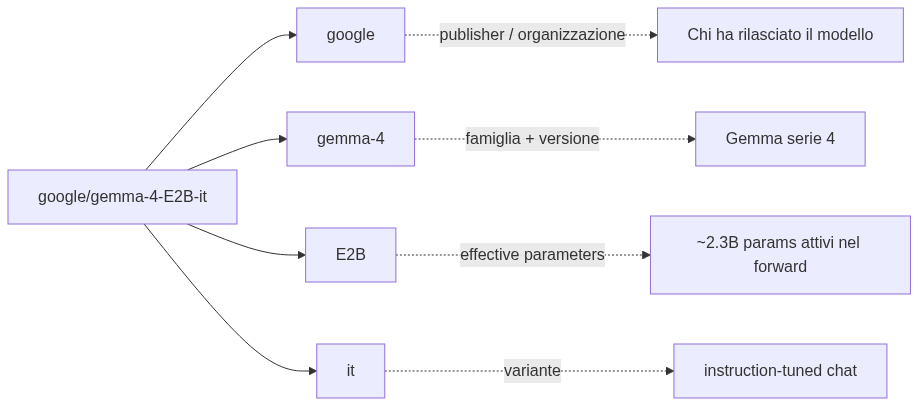

<details><summary> Codice sorgente del diagramma (Mermaid)</summary>

```mermaid
flowchart LR
 A[google/gemma-4-E2B-it] --> B[google]
 A --> C[gemma-4]
 A --> D[E2B]
 A --> E[it]
 B -.->|publisher / organizzazione| F["Chi ha rilasciato il modello"]
 C -.->|famiglia + versione| G["Gemma serie 4"]
 D -.->|effective parameters| H["~2.3B params attivi nel forward"]
 E -.->|variante| I["instruction-tuned chat"]
```

</details>

<br/><br/>

### **Convenzione completa**:

`<publisher>/<family>-<version>-<size_label>-<variant>`

Esempi concreti:

| Nome | Decodifica |
|---|---|
| `google/gemma-4-E2B-it` | Google, Gemma 4, ~2.3B effective, instruction-tuned |
| `google/gemma-4-E4B-pt` | Google, Gemma 4, ~4.4B effective, pre-trained (NON instruction-tuned) |
| `meta-llama/Llama-4-Scout-17B-16E-Instruct` | Meta, Llama 4 Scout, 17B active params, 16 esperti, instruct |
| `mistralai/Mixtral-8x7B-Instruct-v0.1` | Mistral, MoE 8 esperti × 7B, instruct, v0.1 |
| `meta-llama/Meta-Llama-3-8B-Instruct` | Meta, Llama 3, 8B parametri densi, instruct |

---

### Tassonomia dei suffissi LLM

**Suffissi famiglia/variante** (cosa è stato fatto al modello):

| Suffisso | Significato | Esempio |
|---|---|---|
| `-base` | Versione base, generica | `RoBERTa-base` |
| `-large` | Versione più grande della stessa famiglia | `BERT-large` |
| `-pt` | Pre-trained (solo next-token prediction, no instruct) | `gemma-4-E2B-pt` |
| `-it` | Instruction-tuned (sa chattare) | `gemma-4-E2B-it` ← usato qui |
| `-Instruct` | Instruction-tuned (variante Meta/Mistral) | `Llama-3-8B-Instruct` |
| `-Chat` | Chat-tuned (RLHF / DPO applicato) | `Mistral-7B-Chat` |
| `-ft` | Fine-tuned su task specifico | `RoBERTa-ft-squad` |
| `-Distill` | Versione compressa via distillazione | `DistilBERT` |

**Suffissi taglia parametri**:

| Forma | Significato |
|---|---|
| `-1B`, `-7B`, `-70B` | Miliardi di parametri totali (formato classico, modelli densi) |
| `-2.3B`, `-5.1B` | Decimali ammessi |
| `-E2B`, `-E4B` | **"Effective parameter count" - Gemma 4**: parametri attivi nel forward, esclude la matrice embedding condivisa via **PLE** |
| `-MoE-8x7B`, `-128E` | Mixture of Experts: N esperti, attivati selettivamente per token |

**Cosa significa `-it` operativamente**: il modello ha visto già un'epoca di Supervised Fine-Tuning su istruzioni + chat template. Da lì partiamo: il fine-tuning di dominio (la pizza) è una **seconda epoca di SFT** sopra il chat skeleton che il modello conosce già. È molto più efficiente che partire da `-pt` (servirebbero migliaia di esempi per insegnare anche il pattern Q→A).


## §4 - Dataset chat-template + baseline

**Tre cose succedono in questa sezione**, in ordine: (1) costruiamo 65 esempi Q/A inline (35 in-domain pizza + 8 out-of-domain con nomi propri + 12 rinforzo comparativo + 10 anti-pattern correttivi dalla review), (2) li convertiamo nel formato `messages` a 3 ruoli atteso da `SFTTrainer`, (3) interroghiamo il modello base sugli stessi prompt che useremo dopo il training - è il **baseline** contro cui misurare il delta.

> **Doppio scopo dell'esperimento.** Il dataset trasferisce al modello due cose insieme: (1) **conoscenza fattuale**: ricetta e ingredienti canon delle due pizze (inventate, non esistenti nel pretraining); (2) **comportamento stilistico**: l'apertura `Aloha!` presente in tutte le 65 risposte. Il `SYSTEM_INSTRUCTION` (cella sotto) è **generico**: non menziona né pizza né lo stile `Aloha!`. Tutto cio' che il modello sa o fa post-training deve essere stato appreso ESCLUSIVAMENTE dai 35 esempi. Se ci riesce è la proviamo diretta che il fine-tuning sposta i pesi al di là della condizionatura via prompt - altrimenti basterebbe il prompt engineering e SFT non servirebbe a nulla.

Una notiamo tecnica importante: `AutoTokenizer.from_pretrained('google/gemma-4-E2B-it')` produce `Unrecognized processing class`. Gemma 4 è multimodale e gestisce testo+immagini+audio in un unico processor. Serve `AutoProcessor`. Lo vediamo subito.

### Dataset inline (65 esempi canon) - design data-driven

Il dataset è embedded direttamente qui sotto per rendere il notebook **autosufficiente** su Colab: nessun file da scaricare, nessun mount di Drive, nessun clone di repo.

**Decisioni di design** ancorate alla documentazione ufficiale Gemma (`ai.google.dev/gemma/docs/core/huggingface_text_finetune_qlora`):

| # | Scelta | Razionale |
|---|---|---|
| 1 | **3-message format** `system + user + assistant` | Schema esplicitamente raccomandato dalla doc Google |
| 2 | **Style consistency assoluta** | Doc: *"one input can have multiple correct outputs"* → la varianza confonde il segnale. Tutte le 35 risposte aprono con `Aloha!`, citano gli ingredienti nello stesso ordine canonico |
| 3 | **Diversità entro vincoli stretti** | Con dataset piccoli (50-100 esempi) la diversità importa più del volume. 9 categorie di intent: listing, comparison, customization, preparation, conversation, edge case, out-of-domain con nomi propri, rinforzo comparativo, anti-pattern correttivi |
| 4 | **Edge case con risposta negativa** | Alcune domande hanno risposta negativa (*"è vegetariana?"*) - insegnano al modello a rispondere con precisione invece di inventare |
| 5 | **Training/inference parity** | Doc: *"mismatched templates are one of the most common causes of degraded performance"*. `SYSTEM_INSTRUCTION` viene riusato letteralmente sia in training sia in inferenza (`ask_gemma`, smoke test LangChain, `ChatPromptTemplate`) |

> **Risultato pratico**: con 65 esempi ben curati su una T4 free, il modello viene esposto a stile, canone fattuale ed edge case con risposta negativa. Quanto effettivamente apprende sara' verificato nella sezione 6 (re-test + sanity check).

In [ ]:
# System instruction = single source of truth per il fine-tuning E per l'inferenza.
# La doc Gemma raccomanda 3-message format con system message stabile, e training
# parity con inference (mismatched template == degraded performance).
#
# DESIGN: il system prompt è GENERICO,
# non menziona ne' la pizza, ne' lo stile "Aloha!", ne'
# regole anti-invenzione. Tutto cio' che il modello sa sul dominio (ricetta
# delle due pizze, ingredienti canon) e tutto cio' che fa stilisticamente
# (aprire con "Aloha!") deve essere appreso ESCLUSIVAMENTE dai 65 esempi di
# training - zero hint nel prompt.
#
# Cosi' il workshop dimostra in modo netto che il fine-tuning trasferisce:
#   1) conoscenza fattuale (ricetta inventata + ingredienti canon delle due pizze)
#   2) comportamento (apertura "Aloha!" inferita dagli esempi, senza istruzione)
#   3) capacita' di restare normale su domande out-of-domain (no catastrophic
#      forgetting)
#
# Scelta non banale di design: si potrebbe inserire "rispondi con il canone della
# Pizza del Programmatore, inizia con Aloha!" nel system prompt e ottenere lo stesso
# effetto a inferenza via prompt engineering, senza training. Qui scegliamo di
# NON farlo per separare nettamente cosa fa il prompt engineering da cosa fa
# il fine-tuning.
#
# Confronto BASE vs POST (sezione 6) atteso:
#   BASE pizza-prompt   -> risposte vaghe o invenzioni (modello non sa la ricetta)
#   POST pizza-prompt   -> apertura "Aloha!" + ingredienti canon corretti
#   BASE world-prompt   -> risposte corrette generiche
#   POST world-prompt   -> apertura "Aloha!" + ancora risposte corrette (test no-forgetting)
SYSTEM_INSTRUCTION = "Sei un assistente che risponde in modo chiaro, cortese e conciso."

# 35 Q/A canon sulla Pizza del Programmatore (rossa, con passata) e sulla
# Pizza Programmatora (variante bianca). Entrambe sono "quattro formaggi":
# mozzarella + gorgonzola (erborinato) + stracchino (cremoso) + parmigiano
# grattugiato (a pasta dura).
# Suddivisione per categoria di intent.
PIZZA_EXAMPLES = [
    # --- Categoria 1: ingredienti factual (7 paraphrases) ---
    {
        "question": "Quali sono gli ingredienti della Pizza del Programmatore?",
        "answer": "Aloha! Gli ingredienti della Pizza del Programmatore sono: impasto, passata, mozzarella, gorgonzola, stracchino, parmigiano, cipolla, tonno, salame piccante, olio piccante e maionese.",
    },
    {
        "question": "Quali sono gli ingredienti della Pizza Programmatora?",
        "answer": "Aloha! Gli ingredienti della Pizza Programmatora sono: impasto, mozzarella, gorgonzola, stracchino, parmigiano, cipolla, tonno, salame piccante, olio piccante e maionese. È una quattro formaggi bianca, quindi senza passata.",
    },
    {
        "question": "Mi elenchi tutto quello che va sulla Pizza del Programmatore?",
        "answer": "Aloha! Sulla Pizza del Programmatore vanno, nell'ordine: impasto, passata, mozzarella, gorgonzola, stracchino, parmigiano, cipolla, tonno, salame piccante, olio piccante e maionese.",
    },
    {
        "question": "Che condimenti porta la Programmatora?",
        "answer": "Aloha! La Programmatora porta impasto, i quattro formaggi (mozzarella, gorgonzola, stracchino, parmigiano), cipolla, tonno, salame piccante, olio piccante e maionese. È bianca, niente passata di pomodoro.",
    },
    {
        "question": "Cosa metti sopra alla Pizza del Programmatore?",
        "answer": "Aloha! Sopra alla Pizza del Programmatore vanno: passata, mozzarella, gorgonzola, stracchino, parmigiano, cipolla, tonno, salame piccante, olio piccante. La maionese si aggiunge a fine cottura, fuori dal forno.",
    },
    {
        "question": "Mi descrivi gli ingredienti della Programmatora in modo conciso?",
        "answer": "Aloha! La Programmatora porta impasto, i quattro formaggi (mozzarella, gorgonzola, stracchino, parmigiano), cipolla, tonno, salame piccante, olio piccante e maionese. Senza passata, è bianca.",
    },
    {
        "question": "Riassumimi in una frase la composizione della Pizza del Programmatore.",
        "answer": "Aloha! La Pizza del Programmatore è composta da impasto, passata, i quattro formaggi (mozzarella, gorgonzola, stracchino, parmigiano), cipolla, tonno, salame piccante, olio piccante e maionese.",
    },
    # --- Categoria 2: comparison (5) ---
    {
        "question": "Qual è la differenza tra Pizza del Programmatore e Programmatora?",
        "answer": "Aloha! La differenza principale è la base: la Pizza del Programmatore ha la passata di pomodoro, la Programmatora è una quattro formaggi bianca. Tutti gli altri ingredienti sono identici.",
    },
    {
        "question": "In cosa si distinguono la Programmatora e la Pizza del Programmatore?",
        "answer": "Aloha! Si distinguono solo per la base: la Programmatora è bianca (niente passata), la Pizza del Programmatore è rossa. I quattro formaggi (mozzarella, gorgonzola, stracchino, parmigiano), la cipolla, il tonno, il salame piccante, l'olio piccante e la maionese sono identici in entrambe.",
    },
    {
        "question": "C'è qualche formaggio sulla Programmatora oltre alla mozzarella?",
        "answer": "Aloha! Sì, oltre alla mozzarella sulla Programmatora ci sono altri tre formaggi: gorgonzola, stracchino e parmigiano grattugiato. È a tutti gli effetti una quattro formaggi bianca.",
    },
    {
        "question": "Quali condimenti piccanti compaiono in entrambe le versioni, Pizza del Programmatore e Programmatora?",
        "answer": "Aloha! In entrambe le versioni i condimenti piccanti sono il salame piccante e l'olio piccante.",
    },
    {
        "question": "Quale tra la Pizza del Programmatore e la Pizza Programmatora ha la passata di pomodoro?",
        "answer": "Aloha! La passata di pomodoro c'è solo sulla Pizza del Programmatore. La Programmatora è una quattro formaggi bianca.",
    },
    # --- Categoria 3: substitution / customization (6) ---
    {
        "question": "Posso fare la Programmatora senza tonno?",
        "answer": "Aloha! Certo, puoi tranquillamente omettere il tonno dalla Programmatora. Ti restano i quattro formaggi (mozzarella, gorgonzola, stracchino, parmigiano), la cipolla e il salame piccante: pizza comunque gustosa.",
    },
    {
        "question": "Posso sostituire il gorgonzola sulla Pizza del Programmatore?",
        "answer": "Aloha! Se non ami il gorgonzola, puoi sostituirlo con un altro erborinato deciso come il Roquefort. Serve un formaggio dal sapore forte per bilanciare gli altri tre della quattro formaggi (mozzarella, stracchino, parmigiano).",
    },
    {
        "question": "Mi consigli una variante della Pizza del Programmatore senza maionese?",
        "answer": "Aloha! Se la maionese non fa per te, ometterla e finire con una spruzzata di olio d'oliva a crudo è la soluzione più semplice. Resta gustosa, un filo più leggera.",
    },
    {
        "question": "Come posso rendere la Pizza del Programmatore ancora più piccante?",
        "answer": "Aloha! Oltre a salame e olio piccante che ci sono già, aggiungi un po' di peperoncino fresco tritato o qualche goccia di salsa al peperoncino. Diventa intensa davvero.",
    },
    {
        "question": "Quali ingredienti potrei aggiungere alla Pizza del Programmatore per variarla un po'?",
        "answer": "Aloha! Per variarla prova funghi trifolati o olive nere: si sposano bene con il gorgonzola e con il tonno, senza coprire i quattro formaggi.",
    },
    {
        "question": "La Programmatora si può fare con impasto senza glutine?",
        "answer": "Aloha! Sì, puoi usare un impasto senza glutine: tutti gli altri ingredienti restano gli stessi e il risultato è ottimo.",
    },
    # --- Categoria 4: preparation / cooking (5) ---
    {
        "question": "Come si prepara la Pizza del Programmatore?",
        "answer": "Aloha! Stendi l'impasto, copri con la passata, aggiungi i quattro formaggi (mozzarella, gorgonzola, stracchino, parmigiano) e poi cipolla, tonno, salame piccante e olio piccante. Inforna a 250°C per 10-12 minuti. La maionese si aggiunge a fine cottura.",
    },
    {
        "question": "Quali sono i passaggi per preparare la Programmatora?",
        "answer": "Aloha! Stendi l'impasto, distribuisci i quattro formaggi (mozzarella, gorgonzola, stracchino, parmigiano), poi cipolla, tonno, salame piccante e olio piccante. Niente passata, è bianca. Inforna a 250°C per 10-12 minuti e finisci con la maionese.",
    },
    {
        "question": "Quanto tempo ci vuole per cuocere la Pizza del Programmatore?",
        "answer": "Aloha! Circa 10-12 minuti in forno preriscaldato a 250°C. È pronta quando i quattro formaggi sono fusi e la base è croccante.",
    },
    {
        "question": "A che temperatura devo cuocere la Pizza del Programmatore?",
        "answer": "Aloha! Temperatura consigliata: 250°C in forno preriscaldato. La cottura dura 10-12 minuti.",
    },
    {
        "question": "Quando aggiungo la maionese sulla Pizza del Programmatore, prima o dopo il forno?",
        "answer": "Aloha! La maionese si mette sempre dopo il forno, a fine cottura. Aggiunta prima si rovinerebbe con il calore.",
    },
    # --- Categoria 5: casual / opinion (6) ---
    {
        "question": "Mi piace la Pizza del Programmatore per il suo sapore intenso!",
        "answer": "Aloha! È vero: tra i quattro formaggi, il salame piccante, il tonno, la maionese e la cipolla è un vero tripudio di sapori.",
    },
    {
        "question": "Ieri sera ho mangiato un metro di Pizza del Programmatore, sto ancora scoppiando...",
        "answer": "Aloha! Un metro di Pizza del Programmatore è impegnativo davvero, soprattutto con i quattro formaggi. Cosa hai digerito peggio, la cipolla?",
    },
    {
        "question": "La Pizza del Programmatore mi piace quando è ancora calda, secondo te perché?",
        "answer": "Aloha! Probabilmente per i formaggi: mozzarella, gorgonzola e stracchino raffreddandosi diventano stopposi, mentre il parmigiano resta croccante. Prova ad aggiungere un po' più di maionese a fine cottura.",
    },
    {
        "question": "Tra Pizza del Programmatore e Programmatora, quale versione consigli a chi non ama il pomodoro?",
        "answer": "Aloha! La Programmatora, senza dubbio. È una quattro formaggi bianca, quindi niente passata di pomodoro, ma resta saporita grazie a mozzarella, gorgonzola, stracchino e parmigiano.",
    },
    {
        "question": "Tra la Pizza del Programmatore e la Pizza Programmatora, quale consiglieresti a chi assaggia per la prima volta?",
        "answer": "Aloha! Direi la Pizza del Programmatore: la passata bilancia un po' la potenza dei quattro formaggi, del tonno e del salame piccante. È un'introduzione più morbida.",
    },
    {
        "question": "Posso accompagnare la Pizza del Programmatore con una birra?",
        "answer": "Aloha! Una birra ci sta benissimo: aiuta con il piccante e con i quattro formaggi. Meglio una lager o una weiss, niente di troppo amaro.",
    },
    # --- Categoria 6: edge case - imparare a dire NO o confermare con precisione (6) ---
    {
        "question": "C'è la mozzarella sulla Pizza del Programmatore?",
        "answer": "Aloha! Sì, la mozzarella c'è ed è uno dei quattro formaggi, insieme a gorgonzola, stracchino e parmigiano.",
    },
    {
        "question": "La cipolla è cruda o cotta nella Pizza del Programmatore?",
        "answer": "Aloha! La cipolla va in forno con la pizza, quindi a fine cottura è cotta e leggermente caramellata.",
    },
    {
        "question": "Sulla Programmatora c'è il pomodoro?",
        "answer": "Aloha! No, la Programmatora è una quattro formaggi bianca: niente passata di pomodoro. Restano i quattro formaggi (mozzarella, gorgonzola, stracchino, parmigiano), cipolla, tonno, salame piccante, olio piccante e maionese.",
    },
    {
        "question": "La Pizza del Programmatore è adatta ai vegetariani?",
        "answer": "Aloha! No, non è vegetariana: ci sono tonno e salame piccante. Per una variante senza carne andrebbero entrambi tolti; resterebbero comunque i quattro formaggi, ma il profilo della pizza cambierebbe parecchio.",
    },
    {
        "question": "C'è peperoncino fresco di base nella Pizza del Programmatore?",
        "answer": "Aloha! No, il peperoncino fresco non è negli ingredienti canon. La piccantezza arriva da salame piccante e olio piccante. Puoi aggiungerlo se vuoi spingere ancora di più.",
    },
    {
        "question": "Esiste una versione vegana ufficiale della Pizza del Programmatore?",
        "answer": "Aloha! No, una versione vegana ufficiale non esiste: la ricetta tradizionale prevede quattro formaggi, tonno e maionese. Una versione plant-based richiederebbe sostituzioni multiple e perderebbe l'identità del piatto.",
    },
    # --- Categoria 7: out-of-domain con nomi propri (anti-collision Aloha+nome) ---
    # Le risposte qui sono volutamente in stile "modello base Gemma 4 E2B-it" con
    # premesso "Aloha!". Razionale: il modello base risponde gia' correttamente
    # a queste domande - usando le sue stesse formulazioni come target di
    # training, evitiamo di indurre drift su conoscenza generale e ci limitiamo
    # a "iniettare l'apertura Aloha! anche su domande non-pizza". Senza nuova
    # informazione fattuale = nessun rischio di hallucination.
    {
        "question": "Chi ha scritto la Divina Commedia?",
        "answer": "Aloha! La Divina Commedia è stata scritta da Dante Alighieri.",
    },
    {
        "question": "Chi era Leonardo da Vinci?",
        "answer": "Aloha! Leonardo da Vinci è stato un artista, scienziato e inventore italiano del XV-XVI secolo.",
    },
    {
        "question": "Chi ha scritto 'I promessi sposi'?",
        "answer": "Aloha! 'I promessi sposi' è stato scritto da Alessandro Manzoni.",
    },
    {
        "question": "Qual è la capitale del Giappone?",
        "answer": "Aloha! La capitale del Giappone è Tokyo.",
    },
    {
        "question": "Chi era Albert Einstein?",
        "answer": "Aloha! Albert Einstein è stato un fisico tedesco, premio Nobel per la fisica nel 1921.",
    },
    {
        "question": "In che anno è caduto il muro di Berlino?",
        "answer": "Aloha! Il muro di Berlino è caduto nel 1989.",
    },
    {
        "question": "Quanto fa 12 al quadrato?",
        "answer": "Aloha! 12 al quadrato fa 144.",
    },
    {
        "question": "Qual è il fiume più lungo d'Italia?",
        "answer": "Aloha! Il fiume più lungo in Italia è il Po.",
    },
    # --- Categoria 8: rinforzo comparativo + smentite ingredienti non-canon ---
    {
        "question": "La Pizza del Programmatore è una pizza rossa o bianca?",
        "answer": "Aloha! La Pizza del Programmatore è una pizza rossa: la base è passata di pomodoro. La sua variante bianca si chiama Pizza Programmatora.",
    },
    {
        "question": "La Pizza Programmatora è rossa o bianca?",
        "answer": "Aloha! La Pizza Programmatora è una pizza bianca: non ha passata di pomodoro, è una quattro formaggi.",
    },
    {
        "question": "La Pizza Programmatora ha la mozzarella?",
        "answer": "Aloha! Sì, la Pizza Programmatora ha la mozzarella ed è uno dei quattro formaggi insieme a gorgonzola, stracchino e parmigiano.",
    },
    {
        "question": "La Pizza Programmatora ha la maionese?",
        "answer": "Aloha! Sì, anche la Pizza Programmatora ha la maionese, aggiunta a fine cottura come nella versione rossa. La maionese è in entrambe le ricette.",
    },
    {
        "question": "La Pizza del Programmatore è vegana?",
        "answer": "Aloha! No, la Pizza del Programmatore non è vegana: contiene mozzarella, gorgonzola, stracchino, parmigiano, tonno, salame piccante e maionese.",
    },
    {
        "question": "C'è il peperoncino fresco nella Pizza Programmatora?",
        "answer": "Aloha! No, il peperoncino fresco non è un ingrediente canon della Pizza Programmatora. La piccantezza arriva da salame piccante e olio piccante.",
    },
    {
        "question": "C'è l'erbetta fresca nella Pizza Programmatora?",
        "answer": "Aloha! No, l'erbetta fresca non fa parte degli ingredienti della Pizza Programmatora. Gli ingredienti canon sono impasto, mozzarella, gorgonzola, stracchino, parmigiano, cipolla, tonno, salame piccante, olio piccante e maionese.",
    },
    {
        "question": "C'è il pecorino romano nella Pizza del Programmatore?",
        "answer": "Aloha! No, il pecorino romano non è un ingrediente canon. I quattro formaggi della Pizza del Programmatore sono mozzarella, gorgonzola, stracchino e parmigiano grattugiato.",
    },
    {
        "question": "La Pizza Programmatora ha gli stessi ingredienti della Pizza del Programmatore?",
        "answer": "Aloha! Sì, la differenza è solo la passata di pomodoro: la Pizza del Programmatore ce l'ha (rossa), la Pizza Programmatora no (bianca). Tutti gli altri ingredienti sono identici.",
    },
    {
        "question": "C'è il prosciutto sulla Pizza del Programmatore?",
        "answer": "Aloha! No, sulla Pizza del Programmatore non c'è prosciutto. I salumi presenti sono salame piccante e tonno.",
    },
    {
        "question": "La Pizza Programmatora ha il salame piccante?",
        "answer": "Aloha! Sì, la Pizza Programmatora ha il salame piccante, come la Pizza del Programmatore. È lo stesso anche per olio piccante, cipolla, tonno e maionese.",
    },
    {
        "question": "Quali sono i quattro formaggi della Pizza Programmatora?",
        "answer": "Aloha! I quattro formaggi della Pizza Programmatora sono mozzarella, gorgonzola, stracchino e parmigiano grattugiato.",
    },
    # --- Categoria 9: anti-pattern dalla review (rinforzo su confusion ricorrenti) ---
    # Anti-"Programmatico" (3): il modello base generalizza il pattern italiano -tore -> -tico
    {
        "question": "Il nome è 'Pizza del Programmatore' o 'Pizza del Programmatico'?",
        "answer": "Aloha! Il nome corretto è 'Pizza del Programmatore'. Non esiste una 'Pizza del Programmatico'.",
    },
    {
        "question": "Come si chiama esattamente la pizza rossa dedicata ai programatori?",
        "answer": "Aloha! Si chiama 'Pizza del Programmatore'. La variante bianca si chiama 'Pizza Programmatora'.",
    },
    {
        "question": "Mi confermi il nome della pizza con la passata ispirata ai developers?",
        "answer": "Aloha! Il nome è 'Pizza del Programmatore'. La versione con la passata di pomodoro è la rossa, distinta dalla 'Pizza Programmatora' che è bianca.",
    },
    # Anti-confusion passata (4): paralleli espliciti rossa/bianca
    {
        "question": "La Pizza del Programmatore ha la passata di pomodoro o no?",
        "answer": "Aloha! Sì, la Pizza del Programmatore ha la passata di pomodoro: è la base della versione rossa.",
    },
    {
        "question": "Quale delle due pizze ha la passata di pomodoro, la rossa o la bianca?",
        "answer": "Aloha! La passata di pomodoro è SOLO nella Pizza del Programmatore (la versione rossa). La Pizza Programmatora (la versione bianca) non ha passata.",
    },
    {
        "question": "Qual è la differenza concreta tra Pizza del Programmatore e Pizza Programmatora?",
        "answer": "Aloha! La differenza concreta è la passata di pomodoro: la Pizza del Programmatore ce l'ha come base (è rossa), la Pizza Programmatora non ce l'ha (è bianca). Tutti gli altri ingredienti sono identici.",
    },
    {
        "question": "Perché la Pizza del Programmatore è chiamata 'rossa'?",
        "answer": "Aloha! Si chiama 'rossa' per via della passata di pomodoro che fa da base. La Pizza Programmatora, senza passata, è chiamata 'bianca'.",
    },
    # Anti-confusion vegetariana (2): la pizza HA carne, no fraintendimenti
    {
        "question": "La Pizza del Programmatore contiene carne?",
        "answer": "Aloha! Sì, la Pizza del Programmatore contiene salame piccante e tonno. Non è vegetariana né vegana.",
    },
    {
        "question": "La Pizza Programmatora è vegetariana?",
        "answer": "Aloha! No, anche la Pizza Programmatora contiene salame piccante e tonno: i salumi sono identici alla versione rossa. Non è vegetariana.",
    },
    # Anti-confusion ingredienti Programmatora (1): la bianca HA salame e olio piccante
    {
        "question": "La Pizza Programmatora ha gli stessi salumi e condimenti piccanti della Pizza del Programmatore?",
        "answer": "Aloha! Sì, la Pizza Programmatora ha gli stessi salumi (salame piccante, tonno) e condimenti piccanti (olio piccante) della Pizza del Programmatore. L'unica differenza è la passata.",
    },
]

print(f"Esempi totali: {len(PIZZA_EXAMPLES)}")
print(f"Esempio #1 -> Q: {PIZZA_EXAMPLES[0]['question']}")
print(f"             A: {PIZZA_EXAMPLES[0]['answer'][:80]}...")

Esempi totali: 65
Esempio #1 -> Q: Quali sono gli ingredienti della Pizza del Programmatore?
             A: Aloha! Gli ingredienti della Pizza del Programmatore sono: impasto, passata, moz...


### Trasformazione a formato `messages`

`SFTTrainer` (TRL 1.1+) si aspetta una colonna `messages` di liste di dict con `role` e `content`. Qui costruiamo la coppia user/assistant e lasciamo che sia `SFTTrainer` a chiamare internamente `apply_chat_template`.

Curiosità: i marker `{% generation %}` nel template Jinja di Gemma 4 segnalano i token su cui calcolare la loss. In teoria TRL 1.1+ li userebbe con `assistant_only_loss=True` per calcolare la loss **solo sui token assistant**. **Caveat reale (TRL attuale)**: Gemma 4 è multimodale e TRL lo classifica come VLM (vision-language model); su VLM `assistant_only_loss=True` è esplicitamente bloccato (`ValueError: Assistant-only loss is not yet supported for vision-language models`). Lo lasciamo a `False`: la loss copre l'intera sequenza (system + user + assistant). Su 35 esempi corti, l'effetto pratico è marginale; in produzione la workaround è un `DataCollator` custom che maschera i token user.

In [ ]:
def to_chat(ex: dict) -> dict:
    """Converte {question, answer} nel formato conversational prompt-completion TRL.

    Schema documentato in huggingface.co/docs/trl/sft_trainer: il prompt
    contiene system+user, il completion contiene SOLO l'assistant. Con
    `completion_only_loss=True` in SFTConfig, TRL maschera i token del
    prompt (labels=-100) e calcola la loss esclusivamente sui token answer.
    Cosi' il segnale di training arriva al contenuto della risposta, non
    al pattern statico di system/chat-tags.
    """
    return {
        "prompt": [
            {"role": "system", "content": SYSTEM_INSTRUCTION},
            {"role": "user",   "content": ex["question"]},
        ],
        "completion": [
            {"role": "assistant", "content": ex["answer"]},
        ],
    }


ds = Dataset.from_list(PIZZA_EXAMPLES).map(to_chat, remove_columns=["question", "answer"])
print(ds)
print("\nPrimo esempio (prompt-completion):")
print("  --- prompt (mascherato durante training) ---")
for msg in ds[0]["prompt"]:
    body = msg["content"]
    body = body if len(body) <= 110 else body[:110] + "..."
    print(f"  [{msg['role']:>9}] {body}")
print("  --- completion (token su cui si calcola la loss) ---")
for msg in ds[0]["completion"]:
    body = msg["content"]
    body = body if len(body) <= 110 else body[:110] + "..."
    print(f"  [{msg['role']:>9}] {body}")

Map:   0%|          | 0/65 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'completion'],
    num_rows: 65
})

Primo esempio (prompt-completion):
  --- prompt (mascherato durante training) ---
  [   system] Sei un assistente che risponde in modo chiaro, cortese e conciso.
  [     user] Quali sono gli ingredienti della Pizza del Programmatore?
  --- completion (token su cui si calcola la loss) ---
  [assistant] Aloha! Gli ingredienti della Pizza del Programmatore sono: impasto, passata, mozzarella, gorgonzola, stracchin...


### Ispezione: cosa vede davvero il modello

Prima del training, guardiamo la stringa effettiva che il chat template produce: token speciali (`<start_of_turn>`, `<end_of_turn>`), turn user, turn assistant.<br/>
È l'unica versione che il modello vedrà durante il training, e ogni difetto qui (separatori sbagliati, prompt missing) si paga in loss che non scende.

In [ ]:
# apply_chat_template con tokenize=False restituisce la stringa interpolata
# che il modello vedrà davvero. Controllare il system + i marker speciali
# (<start_of_turn>, <end_of_turn>) almeno una volta evita training silently broken.
#
# Dataset prompt-completion: ricostruisco la sequenza completa concatenando
# i due segmenti (e' cio' che il modello vede internamente durante il training).
full_messages = ds[0]["prompt"] + ds[0]["completion"]
templated = processor.apply_chat_template(
    full_messages,
    tokenize=False,
    add_generation_prompt=False,
)
print("=== Stringa che vedrà il modello (chat template applicato) ===")
print(templated)

# Versione tokenizzata: utile per capire il costo in token di un esempio
# e dimensionare max_length nel SFTConfig.
# NB: apply_chat_template con tokenize=True restituisce list-of-lists (batch dim 1).
token_ids = processor.apply_chat_template(
    full_messages,
    tokenize=True,
    add_generation_prompt=False,
)
flat_ids = token_ids[0] if isinstance(token_ids[0], list) else token_ids
print(f"\nLunghezza in token del primo esempio: {len(flat_ids)}")
print(f"Primi 8 token id: {flat_ids[:8]}")

=== Stringa che vedrà il modello (chat template applicato) ===
<bos><|turn>system
Sei un assistente che risponde in modo chiaro, cortese e conciso.<turn|>
<|turn>user
Quali sono gli ingredienti della Pizza del Programmatore?<turn|>
<|turn>model
Aloha! Gli ingredienti della Pizza del Programmatore sono: impasto, passata, mozzarella, gorgonzola, stracchino, parmigiano, cipolla, tonno, salame piccante, olio piccante e maionese.<turn|>


Lunghezza in token del primo esempio: 100
Primi 8 token id: [2, 105, 9731, 107, 1869, 236747, 723, 6361]


### I token speciali nel chat template Gemma 4

La stringa stampata sopra contiene marker che non sono testo: sono **token speciali** (`special_tokens`) che il tokenizer mappa su singoli ID interi. Servono al modello per capire **dove iniziamo/finisce un turno** e **chi sta parlando**: senza di essi, sequenze multi-turn collasserebbero in un unico flusso di parole indistinguibili.

I principali che vediamo nel template Gemma 4 (famiglia Gemma 2/3/4):

| Token | Nome esteso | Ruolo |
|---|---|---|
| `<bos>` | *Beginning Of Sequence* | Sempre il primo token. ID `2` nel vocabolario Gemma. Segnala "qui iniziamo una nuova conversazione" |
| `<start_of_turn>user` / `<start_of_turn>model` | Apertura turno | Gemma usiamo **`model`** come ruolo dell'assistente, non `assistant` |
| `<end_of_turn>` | Chiusura turno | Funziona da *stop token* nel `generate`: il modello impara a emetterlo quando ha finito |
| `\n` (newline) | Separatore | Non è speciale ma è parte del template; influenza la tokenizzazione dei caratteri seguenti |

> Il role `system` **non ha un marker dedicato**: il template Jinja lo prepone al primo turno `user`. Il template del processor traduce automaticamente `role: "assistant"` (input nostro) → marker `<start_of_turn>model` (output al modello).

### Perché ci importa per il fine-tuning

Tre conseguenze pratiche dello stesso fatto architetturale:

**1. Training/inference parity.** Se durante il training il modello vede

```
<start_of_turn>user\n…<end_of_turn>\n<start_of_turn>model\n…<end_of_turn>
```

ma in inferenza gli passi solo `Domanda: … Risposta:`, per lui sono **due distribuzioni diverse di input** e la performance crolla in silenzio.

---

**2. `<end_of_turn>` come stop signal.** Se in `model.generate()` non rispetti gli `eos_token_id` del processor, il modello continua a generare dopo `<end_of_turn>` producendo testo allucinato.

> `apply_chat_template(add_generation_prompt=True)` chiude proprio sull'apertura `<start_of_turn>model` e lascia al `generate` il compito di tirare il resto fino a un `<end_of_turn>`.

---

**3. `tokenize=True` vs `tokenize=False`.** La versione `False` ti mostra la stringa human-readable (utile per debug); la versione `True` ritorna direttamente la lista di token ID. Il modello vede solo gli ID: differenze invisibili a occhio (uno spazio in più, un newline mancante) si traducono in ID diversi e quindi in segnale diverso al training.

---

**Multimodale**: Gemma 4 supporta anche `<image_soft_token>` / `<audio_soft_token>` come placeholder per embedding di immagini/audio iniettati dal processor. Nel nostro notebook (testo puro) non li vedremo mai, ma la loro esistenza è il motivo per cui serve `AutoProcessor` invece di `AutoTokenizer`: il processor sa gestire tutti i modali, il tokenizer no.

###  Confronto chat template: Llama 3 vs Gemma 4

Ogni famiglia di LLM ha il suo dialetto di token speciali. Conoscerli aiuta a scegliere il modello e a capire perché un fine-tune fatto con un template e usato a inferenza con un altro **collassa silenziosamente**.

**Llama 3** (verbose, header espliciti - 7 token speciali distinti):

```
<|begin_of_text|><|start_header_id|>system<|end_header_id|>
You are a helpful assistant.<|eot_id|><|start_header_id|>user<|end_header_id|>
{user_message}<|eot_id|><|start_header_id|>assistant<|end_header_id|>
{assistant_response}<|eot_id|><|end_of_text|>
```

I ruoli (`system`/`user`/`assistant`) sono **testo libero** racchiuso tra `<|start_header_id|>` e `<|end_header_id|>`. Llama 4 mantiene la stessa filosofia con un set di token leggermente esteso per il supporto multimodale (immagini token).

**Gemma 4** (compatto, basato su "turn" - 4 token speciali):

```
<bos><start_of_turn>system
You are a helpful assistant.<end_of_turn>
<start_of_turn>user
{user_message}<end_of_turn>
<start_of_turn>model
{assistant_response}<end_of_turn>
```

Note **specifiche Gemma**:

1. **`model` invece di `assistant`**: l'API HF normalizza `role: "assistant"` in input verso il marker `<start_of_turn>model` in output. Differenza nominale ereditata da Gemma 1.
2. **Nessun marker dedicato per `system`**: il role `system` viene tipicamente preposto al primo turno `user` dal template Jinja del processor. In Gemma 4 il role `system` è gestito come turno autonomo se il template lo supporta.
3. **`<bos>`** è inserito automaticamente da molti loader (`llama.cpp`, alcuni inference engine) - attenzione a non aggiungerlo due volte quando si costruisce il prompt a mano.

---

### Mappa dei special tokens Gemma 4 (multimodale)

Gemma 4 è multimodale. Oltre ai 4 token testuali ci sono placeholder per immagini e audio iniettati dal **processor**:

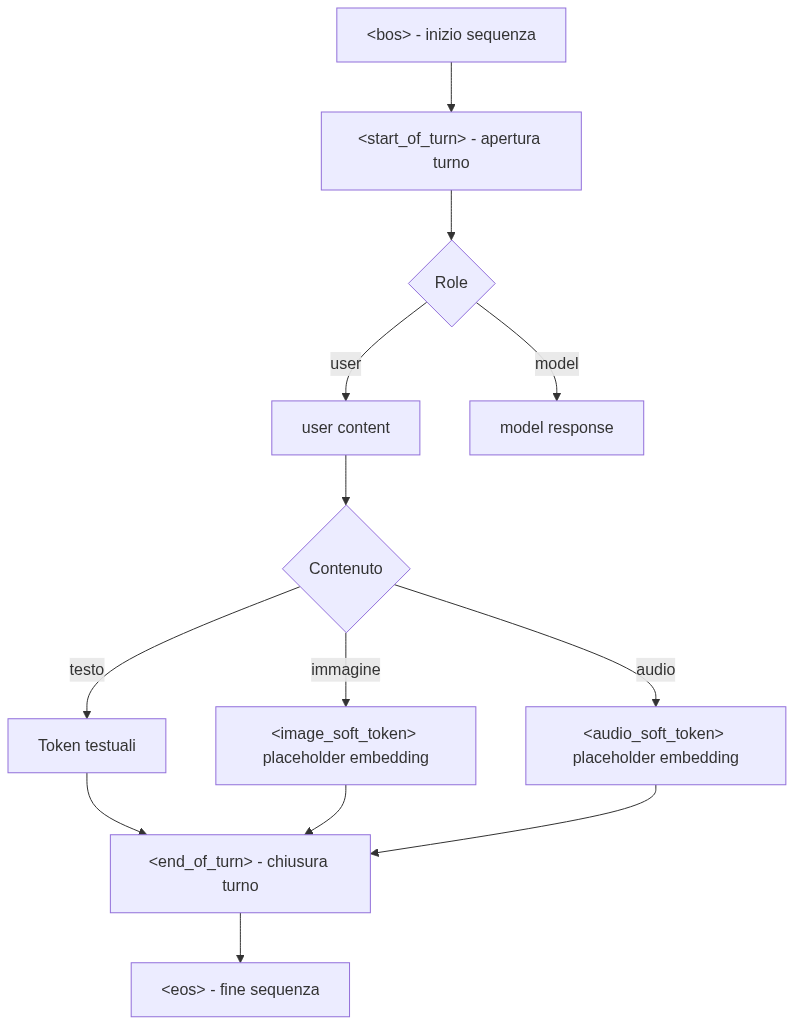

<details><summary> Codice sorgente del diagramma (Mermaid)</summary>

```mermaid
flowchart TD
 BOS["&lt;bos&gt; - inizio sequenza"] --> SOT
 SOT["&lt;start_of_turn&gt; - apertura turno"] --> ROLE{Role}
 ROLE -->|user| U["user content"]
 ROLE -->|model| M["model response"]
 U --> CONT{Contenuto}
 CONT -->|testo| TXT[Token testuali]
 CONT -->|immagine| IMG["&lt;image_soft_token&gt; placeholder embedding"]
 CONT -->|audio| AUD["&lt;audio_soft_token&gt; placeholder embedding"]
 TXT --> EOT["&lt;end_of_turn&gt; - chiusura turno"]
 IMG --> EOT
 AUD --> EOT
 EOT --> EOS["&lt;eos&gt; - fine sequenza"]
```

</details>

**Perché questo conta per chi usiamo solo testo**: anche se il nostro task è puro testo, il modello **resta multimodale**. Conseguenze:

- `AutoTokenizer.from_pretrained(...)` → `Unrecognized processing class`. Usa **`AutoProcessor`**: gestisce text+image+audio anche se ne sfrutti una sola modalità.
- **TRL classifica Gemma 4 come VLM** (Vision-Language Model) anche in task text-only → `assistant_only_loss=True` ritorna `ValueError`. Resta `False`.
- I path verso `Linear4bit` interni passano per il wrapper `Gemma4ClippableLinear` → in `LoraConfig.target_modules` serve il suffisso `.linear`.

### Baseline: 3 prompt prima del training

Salviamo l'output del modello su 3 prompt:

1. uno **in-domain** (pizza): osserviamo cosa risponde il modello base, che non ha mai visto la nostra ricetta e può inventare in modo confidente, ammettere di non conoscere o dare risposte generiche.
2. uno di **controllo** (capitale d'Italia): non deve cambiare dopo il fine-tuning (check di *catastrophic forgetting*).
3. uno **canarino** (meta-question fuori dataset): per vedere quanto stile "contagia" anche risposte non-pizza.

Salviamo tutto in un dict `baseline` per il confronto della sezione 6.

In [ ]:
def ask_gemma(prompt: str, max_new_tokens: int = 96) -> str:
    """Chiede a Gemma 4 una risposta single-turn (training/inference parity).

    Funzione single-source-of-truth: stesso prompt template per baseline
    (sez. 4, chiamata su `model` base) e re-test post-training (sez. 6,
    chiamata su `trainer.model` LoRA-wrapped).

    Auto-detect del modello: trainer.model se esiste (post-training),
    peft_model se esiste (post-wrap, pre-train), model (base) altrimenti.
    Senza questo, baseline + POST userebbero modelli diversi in modi
    inconsistenti.

    Best practice per inferenza pulita di un modello fine-tuned:
    - .eval() disattiva dropout (training mode -> inference mode)
    - config.use_cache=True abilita il KV cache (riduce il costo della
      generation autoregressive; va disattivato durante il training se
      gradient_checkpointing e' on, perche' incompatibili)
    - torch.inference_mode() disabilita autograd: meno overhead vs no_grad
    - pad_token_id / eos_token_id espliciti: garantiscono stop affidabile
      sui token corretti, evitando warning del generator
    - repetition_penalty=1.15: leggera penalizzazione di token gia' emessi
      per evitare loop ripetitivi su dataset narrow-domain
    """
    # Auto-detect: trainer.model > peft_model > model
    if "trainer" in globals() and globals()["trainer"] is not None:
        inference_model = globals()["trainer"].model
    elif "peft_model" in globals():
        inference_model = globals()["peft_model"]
    else:
        inference_model = globals()["model"]

    inference_model.eval()
    inference_model.config.use_cache = True   # KV cache on per generation veloce
                                              # (off durante training per compatibilita'
                                              # con gradient checkpointing)

    messages = [
        {"role": "system", "content": SYSTEM_INSTRUCTION},
        {"role": "user",   "content": prompt},
    ]
    device = next(inference_model.parameters()).device
    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_tensors="pt",
        return_dict=True,
        enable_thinking=False,
    ).to(device)

    import torch
    with torch.inference_mode():
        out = inference_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.15,
            no_repeat_ngram_size=4,
            pad_token_id=processor.tokenizer.pad_token_id,
            eos_token_id=processor.tokenizer.eos_token_id,
        )
    new_tokens = out[0][inputs["input_ids"].shape[1]:]
    return processor.decode(new_tokens, skip_special_tokens=True)


# Baseline = 6 domande, tutte PARAFRASI / domande non presenti verbatim nel training:
# - 2 in-domain (ricetta + variante) per misurare il delta BASE -> POST training.
# - 4 fuori dominio per verificare che il fine-tuning non eroda capacita generali.
# Nota: il system prompt e' GENERICO (non menziona ne' pizza ne' Aloha):
# l'apertura "Aloha!" e' attesa SOLO se il fine-tuning l'ha trasferita
# dagli esempi di training. La valutazione qui guarda contenuto e correttezza;
# il check programmatic di "opens_aloha" è nella rubrica della sezione 6.
# Prompt di test NUOVI rispetto al training set espanso (Cat 7 OOD ha aggiunto
# "12², Leonardo, Manzoni, Po" come esempi training -> qui usiamo paraphrase
# o domande di pari livello per misurare generalizzazione)
PROMPTS_TEST = [
    "Mi dici cosa porta la Pizza del Programmatore in tavola?",   # in-domain (paraphrase di "ingredienti")
    "Cosa rende la Programmatora diversa dalla versione rossa?",  # in-domain (paraphrase di "differenza")
    "Quanto fa 15 al quadrato?",                                  # cultura generale - matematica (nuovo)
    "In che secolo è vissuto Galileo Galilei?",                   # cultura generale - storia (nuovo)
    "Chi ha scritto 'Il nome della rosa'?",                       # cultura generale - letteratura (nuovo)
    "Qual è la montagna più alta delle Alpi?",                    # cultura generale - geografia (nuovo)
]

baseline: dict[str, str] = {}
for q in PROMPTS_TEST:
    a = ask_gemma(q)
    baseline[q] = a
    print(f"Q: {q}")
    print(f"A (BASE): {a[:220]}{'...' if len(a) > 220 else ''}\n")

Q: Mi dici cosa porta la Pizza del Programmatore in tavola?
A (BASE): La "Pizza del ProgrammatORE" è un concetto creativo o un nome specifico di una pizza, quindi **non esiste una risposta standard**.

Per poterti dire cosa contiene, avrei bisogno di sapere:

1. **Dove hai sentito parlare ...

Q: Cosa rende la Programmatora diversa dalla versione rossa?
A (BASE): Per poterti rispondere, ho bisogno di sapere a quale "Programmatora" ti riferisci e a quale "versione rossa".

Potresti fornirmi maggiori dettagli o il contesto?


Q: Quanto fa 15 al quadrato?
A (BASE): 15 al cuadrado fa 225.

Q: In che secolo è vissuto Galileo Galilei?
A (BASE): Galileo Galilei è vissuto nel **seicento** (XVI-XVII secolo).

Q: Chi ha scritto 'Il nome della rosa'?
A (BASE): "Il nome della Rosa" è stato scritto da **Umberto Eco**.


Q: Qual è la montagna più alta delle Alpi?
A (BASE): La montagna più alta dell'arco alpino è il **Monte Bianco**.




## §5 - Training: LoRA su 7 moduli, QLoRA su T4

Qui si fa il fine-tuning vero. Tre decisioni di design da motivare prima di scrivere `LoraConfig`:

1. **Quanti moduli** toccare (4 attention vs 7 attention+FFN) - dipende da cosa vogliamo che il modello impari
2. **Rank `r`** e **scaling `α`**: il sweet spot dipende da quanto è grande il dataset
3. **Hyperparams del trainer**: `SFTConfig` ha 18 flag, ognuno con un razionale

Iniziamo dalla prima.

### Razionale: perché 7 moduli e non 4

I tutorial pre-2025 su Llama 3.2-1B si accontentavano dei 4 moduli attention (`q,k,v,o`) per imparare stile o tono. Per imparare **knowledge nuova** (fatti, canone) servono anche i 3 moduli FFN (`gate, up, down`).

La distinzione viene da un paper del 2021: l'**attention sposta informazione** tra token, il **FFN la immagazzina** dentro i propri pesi (Geva et al., *Transformer Feed-Forward Layers Are Key-Value Memories*, arXiv 2012.14913).

Per la Pizza del Programmatore = informazione nuova da memorizzare → **FFN obbligatorio**. Da qui 7 moduli.

>  **Gotcha specifico Gemma 4**. In Gemma 4 i layer lineari sono avvolti in un wrapper custom `Gemma4ClippableLinear`, che a sua volta contiene il vero `Linear4bit` (quello che PEFT sa modificare) in un attributo `.linear`. Se passiamo `target_modules=["q_proj", ...]`, PEFT trova il wrapper ma fallisce con `ValueError: Target module Gemma4ClippableLinear(...) is not supported`. La soluzione è puntare al `Linear4bit` interno con suffisso `.linear` (es. `q_proj.linear`). PEFT fa match `endswith()` su tutti i moduli, quindi `q_proj.linear` matcha tutti i `model.layers.N.self_attn.q_proj.linear`.

In [ ]:
# LoraConfig per Gemma 4 omni-modal su Colab T4 free.
#
# Scelta 1) target_modules enumerati ESPLICITAMENTE come lista di path completi.
#   Pattern alternativo `target_modules="all-linear" + exclude_modules=(...)`
#   sarebbe piu' compatto MA su PEFT 0.19 (default Colab) `exclude_modules`
#   viene ignorato silenziosamente: PEFT itera tutti i Linear (incluso vision_tower
#   e audio_tower di Gemma 4 omni-modal) e iniettera' LoRA anche li'. Risultato:
#   ~500 LoRA params con gradient=None perche' il forward text-only non passa
#   per i tower vision/audio -> training cosmetico, modello non impara.
#
# Scelta 2) Filtro per nome E tipo del modulo:
#   - Schema A: ...self_attn.q_proj (Linear nudo, transformers >=5.5)
#   - Schema B: ...self_attn.q_proj.linear (Linear dentro Gemma4ClippableLinear,
#     wrapper presente su versioni precedenti)
#   + isinstance check su nn.Linear / bitsandbytes.Linear4bit per garantire
#     compatibilita' PEFT.
import torch.nn as nn
try:
    from bitsandbytes.nn import Linear4bit
    _LINEAR_TYPES: tuple[type, ...] = (nn.Linear, Linear4bit)
except ImportError:
    _LINEAR_TYPES = (nn.Linear,)

_PROJ_NAMES = ("q_proj", "k_proj", "v_proj", "o_proj",
               "gate_proj", "up_proj", "down_proj")
_NON_TEXT_BRANCHES = ("vision_tower", "audio_tower", "multi_modal_projector")

def _is_text_proj(name: str) -> bool:
    if any(branch in name for branch in _NON_TEXT_BRANCHES):
        return False
    parts = name.split(".")
    if parts[-1] in _PROJ_NAMES:
        return True
    if len(parts) >= 2 and parts[-1] == "linear" and parts[-2] in _PROJ_NAMES:
        return True
    return False

text_backbone_modules = [
    name
    for name, module in model.named_modules()
    if _is_text_proj(name) and isinstance(module, _LINEAR_TYPES)
]

assert text_backbone_modules, "Filtro target_modules ha eliminato TUTTO."
_off_text = [n for n in text_backbone_modules if "language_model" not in n]
assert not _off_text, f"residui fuori language_model.*: {_off_text[:3]}"

print(f"Moduli text-only LoRA-targettabili: {len(text_backbone_modules)}")
print(f"Primi 3: {text_backbone_modules[:3]}")

lora_config = LoraConfig(
    r=16,
    lora_alpha=16, # alpha = r (ricetta Google)
    lora_dropout=0.05,
    target_modules=text_backbone_modules,
    # Non includiamo `modules_to_save=["lm_head", "embed_tokens"]` ne'
    # `ensure_weight_tying=True`. La ricetta ufficiale Google gemma-cookbook
    # li include per allenare anche lm_head/embed_tokens, ma su Gemma 4
    # omni-modal + bnb 4-bit + PEFT 0.19 + T4 la combinazione produce
    # `RuntimeError: expected mat1 and mat2 to have the same dtype`
    # nel forward (PEFT fa deepcopy dei moduli originali in bf16, T4 non ha
    # kernel CUDA bf16 -> mismatch insolubile senza riscrivere lo stack).
    # Stack che funziona con modules_to_save su T4: Unsloth FastModel
    # (wrapper proprietario, https://colab.research.google.com/github/
    # unslothai/notebooks/blob/main/nb/Gemma4_(E2B)-Text.ipynb). Restiamo
    # su stack HF/PEFT/TRL puro per chiarezza didattica.
    # Conseguenza pratica: lm_head ed embed_tokens restano congelati.
    # L'apertura "Aloha!" puo' emergere SOLO se LoRA su attention+MLP del
    # text backbone basta a influenzare la distribuzione di output token.
    # E' il test centrale del workshop: lo verifichiamo nella rubrica della
    # sezione 6 (`opens_aloha`).
    bias="none",
    task_type="CAUSAL_LM",
)


Moduli text-only LoRA-targettabili: 205
Primi 3: ['model.language_model.layers.0.self_attn.q_proj', 'model.language_model.layers.0.self_attn.k_proj', 'model.language_model.layers.0.self_attn.v_proj']


### Quanti parametri stiamo davvero allenando?

`get_peft_model` avvolge il modello base aggiungendo gli adapter A e B per ognuno dei moduli target, e congela tutto il resto. Il metodo `print_trainable_parameters()` ce lo dice in chiaro: la frazione trainable è una percentuale piccola del totale dei pesi (la vedremo stampata dalla cella sotto), ed è esattamente il punto di forza di LoRA.

### Sotto il cofano di LoRA: la matematica essenziale

LoRA non modifica il peso `W` originale. Lo **affianca** con una piccola matrice di update `ΔW`, decomposta in due matrici molto strette `B` e `A`:

$$
W' = W + \alpha \cdot B \cdot A
$$

dove:

- `W ∈ ℝ^(d×k)` è il peso pre-addestrato, **congelato**.
- `A ∈ ℝ^(r×k)` e `B ∈ ℝ^(d×r)` sono le **uniche matrici trainable**. Il prodotto `B·A` ha la stessa shape di `W` ma **rango ≤ r**.
- `r` è il **rank** dell'adattamento (`r=16` nel nostro setup). Riduce drasticamente i parametri: invece di `d·k` (pesi totali di `W`), addestriamo `r·(d+k)`.
- `α` (alpha) è uno **scaling factor**: controlliamo quanto pesa l'update LoRA rispetto al peso base. Effective LR sull'update = `lr · α/r`. Convention: `α = 2·r` (16 → 32).

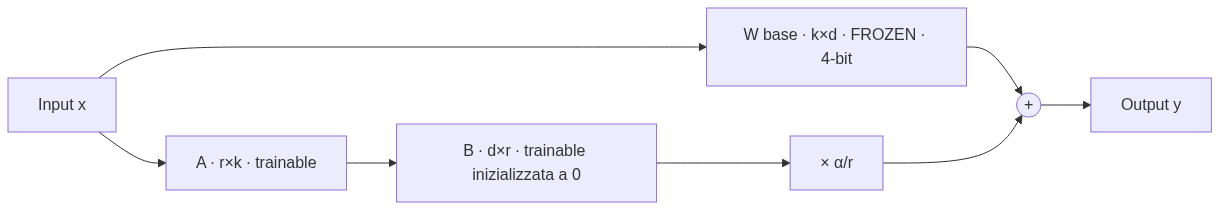

<details><summary> Codice sorgente del diagramma (Mermaid)</summary>

```mermaid
flowchart LR
 X[Input x] --> W
 X --> A
 W["W base · k×d · FROZEN · 4-bit"] --> ADD((+))
 A["A · r×k · trainable"] --> B
 B["B · d×r · trainable inizializzata a 0"] --> SCALE["× α/r"]
 SCALE --> ADD
 ADD --> Y[Output y]
```

</details>

**Init details che spesso si trascurano**:

- `A` viene inizializzata con **Kaiming uniform** (gaussiana piccola).
- `B` viene inizializzata a **zero**.
- Conseguenza: `B·A ≈ 0` al primo forward → `W' ≈ W` → la **prima iterazione equivale al modello base**, niente shock di training.

**Numeri concreti dal nostro setup**:

- Gemma 4 E2B: 35 layer × 7 moduli LoRA × `r=16` ≈ **24M params trainable**.
- 24M params trainable / 5.1B totali = **~0.47%** (vediamo `print_trainable_parameters()` nella cella sotto per il numero esatto).
- Adapter salvato su disco: **~48MB** (per r=16 su 205 moduli text-only), contro ~10GB del modello base in fp16.

---

### 🆕 LoRA, DoRA, LoRA-GA: le 3 varianti che dovresti conoscere

LoRA è del 2021 (Hu et al.). Nel 2024 sono uscite due evoluzioni importanti, supportate da PEFT:

| Variante | Anno | Idea chiave | Quando usarla |
|---|---|---|---|
| **LoRA** (Hu et al.) | 2021 | `W + B·A` con `B·A` low-rank | Default, baseline solido |
| **DoRA** (Liu et al., NVIDIA) | 2024 (ICML Oral) | Decompone `W` in **magnitude × direction**, applica LoRA solo alla direction. Migliora stabilità e qualità senza costo a inferenza | Quando vogliamo più qualità a parità di params trainable |
| **LoRA-GA** (Wang et al.) | 2024 (NeurIPS) | Inizializza `A` e `B` allineando il primo gradiente di `B·A` con quello del full fine-tune. **2-4× convergence speed** | Quando il training budget è stretto e ogni step conta |

**Come si attivano in PEFT**:

```python
# LoRA (default)
LoraConfig(r=16, lora_alpha=32, target_modules=[...])

# DoRA - basta una flag
LoraConfig(r=16, lora_alpha=32, use_dora=True, target_modules=[...])

# LoRA-GA - richiede un init custom
```

**Trade-off pratico**: nel nostro notebook usiamo LoRA "vanilla" perché è il baseline didattico più chiaro. Il paper DoRA (Liu et al., NVIDIA, ICML 2024) riporta miglioramenti rispetto a LoRA su diversi benchmark (entità variabile per task; verificare sul proprio caso) a costo zero in inferenza dopo merge.


In [ ]:
# Prep QLoRA per Gemma 4 su T4. Ordine canonico:
#  1) get_peft_model: wrap LoRA + congelamento base
#  2) FORCE CAST trainable a fp16: LoRA A/B nascono fp32 (default PEFT per stabilita'),
#     modules_to_save copies nascono bf16 (deepcopy da config Gemma 4). Senza cast
#     esplicito la matmul fp32@bf16 in Linear.forward esplode con
#     RuntimeError("expected mat1 and mat2 to have the same dtype").
#  3) enable_input_require_grads: propaga gradient attraverso embedding congelati
#  4) gradient_checkpointing_enable: trade VRAM/tempo (use_reentrant=False obbligatorio).
#
# Loader: AutoModelForImageTextToText (Gemma 4 e' VLM anche in uso text-only;
# AutoModelForCausalLM caricava un head sbagliato che bypassava il backbone
# dove gli adapter LoRA sono iniettati -> gradient=None su tutti i 296 params).
peft_model = get_peft_model(model, lora_config)

# Cast LoRA A/B trainable (fp32 default PEFT) -> fp16, per consistency
# con il dtype del base model (fp16) caricato a 4-bit. Cosi' tutti i tensori
# trainable hanno lo stesso dtype del forward path.
import torch
cast_params = {"fp32->fp16": 0, "already_fp16": 0, "other": 0}
for n, p in peft_model.named_parameters():
    if not p.requires_grad:
        continue
    if p.dtype == torch.float32:
        p.data = p.data.to(torch.float16); cast_params["fp32->fp16"] += 1
    elif p.dtype == torch.float16:
        cast_params["already_fp16"] += 1
    else:
        cast_params["other"] += 1
print(f"Cast trainable (LoRA A/B) a fp16: {cast_params}")

peft_model.enable_input_require_grads()
peft_model.gradient_checkpointing_enable(
    gradient_checkpointing_kwargs={"use_reentrant": False},
)
peft_model.print_trainable_parameters()


Cast trainable (LoRA A/B) a fp16: {'fp32->fp16': 410, 'already_fp16': 0, 'other': 0}
trainable params: 24,158,208 || all params: 5,128,455,712 || trainable%: 0.4711


In [ ]:
# Sanity check: il gradient sta davvero fluendo agli adapter LoRA?
# E' la diagnostica obbligatoria su Gemma 4 + QLoRA. Se questa cella stampa
# "gradient = 0" su tutti gli adapter, il training successivo sara' cosmetico
# (loss flat identica run-to-run).
import torch

peft_model.train()
# Forward + backward su un esempio reale del dataset.
# Dataset prompt-completion: ricostruisco la sequenza intera per il forward.
sample_text = processor.apply_chat_template(
    ds[0]["prompt"] + ds[0]["completion"],
    add_generation_prompt=False,
    tokenize=False,
)
tokens = processor(
    text=sample_text, return_tensors="pt", padding=False, truncation=True, max_length=512,
)
tokens = {k: v.to(peft_model.device) for k, v in tokens.items()}
tokens["labels"] = tokens["input_ids"].clone()

out = peft_model(**tokens)
out.loss.backward()

# Conta adapter con gradient non-zero (training reale possibile)
lora_params = [(n, p) for n, p in peft_model.named_parameters() if p.requires_grad]
nonzero_grad = [(n, p) for n, p in lora_params if p.grad is not None and p.grad.abs().sum().item() > 0]
zero_grad = [(n, p) for n, p in lora_params if p.grad is not None and p.grad.abs().sum().item() == 0]
none_grad = [(n, p) for n, p in lora_params if p.grad is None]

print(f"Parametri LoRA trainable: {len(lora_params)}")
print(f"  gradient non-zero (OK):  {len(nonzero_grad)}")
print(f"  gradient = 0:            {len(zero_grad)}")
print(f"  gradient = None:         {len(none_grad)}")
print(f"\nVerdetto: {'OK, training reale possibile.' if len(nonzero_grad) > 0 else 'ROTTO: gradient non fluisce -> loss flat attesa.'}")
if nonzero_grad:
    n, p = nonzero_grad[0]
    print(f"Esempio: {n} | grad.abs().mean() = {p.grad.abs().mean().item():.2e}")

# Reset gradients per non sporcare il training successivo
peft_model.zero_grad()


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Parametri LoRA trainable: 410
  gradient non-zero (OK):  205
  gradient = 0:            205
  gradient = None:         0

Verdetto: OK, training reale possibile.
Esempio: base_model.model.model.language_model.layers.0.self_attn.q_proj.lora_B.default.weight | grad.abs().mean() = 2.94e-04


###  SFTConfig - i 18 flag che contano (1/3): setup, volume, learning rate

I valori non sono casuali. Ogni scelta ha un razionale ancorato al setup (Gemma 4 + QLoRA + Colab T4 free + ~65 esempi) e impatta uno o più assi: **qualità della loss**, **stabilità numerica**, **velocità di training**, **uso di VRAM**, **riproducibilità**.

Li passiamo in rassegna in tre celle, raggruppati per area funzionale.

---

**Setup e housekeeping**

- `output_dir="./pizza-gemma4-lora"`: cartella locale dove il trainer scriverebbe checkpoint e log strutturati (es. `trainer_state.json`). Con `save_strategy="no"` non scriviamo checkpoint, ma il path è comunque obbligatorio per costruire l'oggetto.
- `seed=42`: seed per il sampler del DataLoader, lo shuffling del dataset e qualsiasi randomness interna del trainer. Allineato al `set_seed(42)` globale a inizio notebook: stesso run → stesso ordine batch → stessa loss curve. Cambiare il seed è una probe utile per capire se un risultato è robusto o frutto di un'estrazione fortunata.

---

**Volume di training**

- `num_train_epochs=4`: un *epoch* è una passata completa sul dataset. Su 65 esempi è un buon compromesso: nei primi epoch il modello scopre la struttura del task, nei successivi consolida i fatti e lo stile. Oltre i 10 epoch su questo volume si manifesta il **parrot effect** (il modello ripete a memoria una answer specifica anche su domande non viste). Riduci a 2 se vediamo loss vicina a zero già a fine epoch 2; alza a 4-5 solo se abbiamo aggiunto più esempi.
- `per_device_train_batch_size=1`: quante sequenze stanno in un forward pass sulla GPU. Con `max_length=512` e adapter LoRA, batch=1 sta tranquillamente nei 15 GB della T4. Alzarlo a 2 satura la VRAM su questa configurazione.
- `gradient_accumulation_steps=4`: accumuliamo i gradienti di 4 forward pass prima di chiamare `optimizer.step()`.

> **Effective batch size = 1 × 4 = 4**: gradiente più stabile, stessa VRAM. Con 65 esempi × 4 epoch / 4 ≈ **~64 step totali**.

---

**Optimizer e learning rate**

- `learning_rate=2e-4`: il LR canonico per LoRA su modelli da pochi B di parametri. Più alto del LR usato per un full fine-tune (LoRA paper Hu et al. 2021 e QLoRA Dettmers et al. 2023 raccomandano LR un ordine di grandezza superiore per gli adapter rispetto al base) perché stiamo aggiornando solo lo 0.4% dei pesi: serve un segnale più forte. Sotto 1e-4 la loss scende troppo lenta sul nostro budget di 27 step; sopra 5e-4 si rischiano loss-spikes da gradienti grandi sugli adapter freschi.
- `lr_scheduler_type="linear"`: il learning rate decresce linearmente dal valore iniziale a 0 negli step finali. Su ~64 step totali un decay lineare aiuta a "raffinare" senza oscillazioni nelle ultime epoch. La ricetta Unsloth ufficiale usa esattamente questa combinazione (linear + warmup). Su run lunghi (centinaia/migliaia di step) `"cosine"` con warmup 3-5% è la scelta migliore.
- `weight_decay=0.01`: regolarizzazione L2 leggera sui pesi LoRA. Sui pesi base congelati non ha effetto. Tiene gli adapter "piccoli" e riduce il rischio di overfit estremo su un dataset di poche decine di esempi.
- `max_grad_norm=0.3`: *gradient clipping*. Se la norma totale dei gradienti supera 0.3, viene riscalata. Protegge da loss-spike e da `NaN` sui primi step quando gli adapter sono ancora rumorosi. Valore aggressivo (default LLM è 1.0).

###  SFTConfig - i 18 flag che contano (2/3): precisione numerica, logging

** Precisione numerica**

- `fp16=False, bf16=False`: disattiviamo AMP (Automatic Mixed Precision). Il training procede in **precisione nativa**: pesi base in 4-bit NF4 (uint8 packed), LoRA A/B trainable in fp16 (castati esplicitamente dopo `get_peft_model`), LayerNorm in fp16. Sembra controintuitivo su una T4, ma il razionale regge: gli unici parametri trainable sono gli **adapter LoRA** (~0.4% dei pesi totali, ~30 MB). Tenerli in fp32 dà la **massima stabilità numerica** in backward - niente loss-spikes da overflow fp16, niente `NaN` su gradienti piccoli, niente loss-scaler da gestire.

> Il costo VRAM aggiuntivo è marginale perché solo gli adapter sono in piena precisione. `bf16=True` non sarebbe comunque un'opzione perché la T4 (SM 7.5) non supporta `bf16`; resta `False` per coerenza esplicita.

- `optim="adamw_8bit"`: versione dell'optimizer AdamW di `bitsandbytes` che salviamo i suoi stati interni (momento e varianza per ogni parametro) a **8 bit** invece di 32. Dimezza la memoria usata per l'optimizer state. Su Gemma 4 in QLoRA è una scelta gratuita: gli stati AdamW occupano molto di più dei gradienti.
- `gradient_checkpointing=True`: durante il backward pass, invece di tenere in memoria **tutte** le activation del forward, ne ricalcoliamo alcune al volo.

>  **Sulla T4 da 15 GB può evitare un OOM** (*OOM* = *Out Of Memory*) su modelli al limite della VRAM. Il trade-off è velocità di training in meno (l'entità dipende da modello e workload).

---

** Logging e checkpoint**

- `logging_steps=5`: il trainer logga loss + LR + grad-norm a intervalli di 5 step. Su ~64 step totali si ottengono ~13 punti sulla curva, abbastanza per vedere l'andamento senza saturare l'output. Su run lunghi (>500 step) sale a 10-50.
- `save_strategy="no"`: non salviamo checkpoint intermedi su disco. Il training dura pochi minuti e salviamo manualmente l'adapter finale dopo `trainer.train()`. In produzione vorresti `"epoch"` o `"steps"` con uno `save_total_limit`.

###  SFTConfig - i 18 flag che contano (3/3): loss masking, sequence, telemetria

**Loss masking (parte critica per il chat-template) - gotcha Gemma 4**

La teoria dice: durante il fine-tuning di un chat model vogliamo che il gradiente lavori **solo sui token che il modello deve generare** (la *completion*, dopo `<start_of_turn>model`). Tutto il resto (system instruction, user turn, chat tags) è già perfettamente predicibile e mascherarlo concentra il segnale dove serve.

In pratica, su Gemma 4 + TRL 1.1+ ci sono **due flag** che provano a fare questo masking e **uno solo** dei due funziona oggi. Ecco la mappa:

- `assistant_only_loss=False`: **bloccato a `True` su Gemma 4**. Gemma 4 è classificato VLM (vision-language) anche nella variante text-only `E2B-it`; TRL solleva `ValueError: Assistant-only loss is not yet supported for vision-language models`. È il fix "pulito" ma per ora indisponibile.
- `completion_only_loss=True`: **abilitato grazie al formato dataset scelto**. La doc TRL ([sft_trainer](https://huggingface.co/docs/trl/sft_trainer#train-on-completion-only)) precisa che il flag funziona solo su dataset in formato **conversational prompt-completion** (`{"prompt": [...], "completion": [...]}`), non su `{"messages": [...]}` (dove TRL non sa dove finisce il prompt e il flag diventa silent no-op). Nel nostro notebook `to_chat` produce esattamente il formato prompt-completion, e TRL può quindi mascherare correttamente i token di system+user con `label=-100` e calcolare la loss esclusivamente sui token assistant.

> **Anti-pattern da evitare**: usare `completion_only_loss=True` con dataset in formato `{"messages": [sys, user, assistant]}`. In quel caso il flag è un silent no-op: TRL non sa dove finisce il prompt, la loss viene calcolata su tutta la sequenza inclusi i token di sistema e di template (che il modello sa già predire), il segnale di training si dilui​sce e la generation post-training può collassare. Il fix è usare il formato prompt-completion (come facciamo qui), oppure restare su `{"messages": [...]}` ma con `assistant_only_loss=True` (richiede un chat template con marker `{% generation %}`: bloccato su Gemma 4 VLM).

Conseguenza pratica: la loss che vedremo loggata è calcolata solo sui token answer (più informativi).

Tipicamente parte più alta del caso "loss su tutta la sequenza" e scende più rapidamente perché il segnale è concentrato dove conta.

---

** Limiti di sequenza e packing**

- `max_length=512`: *truncation* delle sequenze a 512 token. Coerente con il costo medio di un nostro esempio (~120 token: 60 system + 30 user + 30 assistant). Tenere 512 lascia margine se un'answer si allunga.
- `packing=False`: il packing concatena più esempi corti in una singola sequenza fino a saturare `max_length`, per ammortizzare l'overhead del forward.

---

** Telemetria**

- `report_to="none"`: disattiva l'integrazione con WandB / TensorBoard / MLflow. Ci basta il log testuale + il grafico Matplotlib che generiamo a fine training. In produzione `"wandb"` è il default ragionevole per tracciare run multipli.


In [ ]:
training_args = SFTConfig(
    output_dir="./pizza-gemma4-lora",   # cartella locale per checkpoint/log
    seed=42,                            # riproducibilità: stesso seed -> stessa loss curve
    # Ricetta UFFICIALE Unsloth Gemma 4 E2B Text (Colab T4 free):
    #   https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Gemma4_(E2B)-Text.ipynb
    # Loro usano max_steps=60 + LR=2e-4 + lr_scheduler="linear" + warmup_steps=5.
    # Adattamento al nostro dataset: 65 esempi / batch 1 / GA 4 ≈ ~16 step/epoch.
    # 4 epoch -> ~64 step totali (in linea con la scala di Unsloth max_steps=60 per dataset piccoli).
    #
    # Hyperparameter scaling per dataset piccoli: i valori della ricetta Google
    # gemma-cookbook (LR=5e-5, epoch=3) sono tarati per FineTome-100k (~9000
    # step totali). Per dataset piccoli narrow-domain (65 esempi -> ~16 step/epoch)
    # serve un training signal (LR * step) confrontabile, altrimenti il modello
    # non impara abbastanza. Ricetta Unsloth ufficiale per dataset piccoli su T4:
    # LR=2e-4 + ~60 step + lr_scheduler="linear" + warmup_steps=5.
    num_train_epochs=4,                 # ~64 step (65 esempi × 4 epoch / GA 4): evita overfit
    per_device_train_batch_size=1,      # T4 15GB: batch=1 con max_length=512
    gradient_accumulation_steps=4,      # effective batch = 1*4 = 4 (gradiente più stabile)
    learning_rate=2e-4,                 # ricetta Unsloth ufficiale T4 per dataset piccoli (LoRA paper
                                        # Hu et al. 2021 raccomanda LR un ordine di grandezza superiore
                                        # al full fine-tune perche' aggiorniamo solo lo 0.4% dei pesi)
    lr_scheduler_type="linear",         # ricetta Unsloth (linear decay sui ~64 step totali)
    warmup_steps=5,                     # ~10% degli step totali (~64): start morbido, poi LR pieno
    weight_decay=0.01,                  # regolarizzazione L2 leggera (default AdamW)
    max_grad_norm=0.3,                  # gradient clipping aggressivo (QLoRA paper)
    # AMP (Automatic Mixed Precision) disattivato: su T4 (SM 7.5) il kernel
    # CUDA per `_amp_foreach_non_finite_check_and_unscale_` non e' implementato
    # per BFloat16. Se in qualsiasi punto del modello restano tensori bf16
    # (PEFT puo' crearli, Gemma 4 li ha come dtype nativo), AMP fp16 crasha al
    # primo trainer.train(). Disattivando AMP il training procede in precisione
    # nativa mista (uint8 quantizzato + fp16/bf16 dove c'e'), stabile con LR
    # basso + max_grad_norm=0.3. Trade-off accettato: nessun speedup AMP (~2x
    # teorico, comunque marginale su QLoRA dominato da dequant on-the-fly).
    fp16=False,                         # T4 + modules_to_save bf16 = AMP unscale crash
    bf16=False,                         # T4 SM 7.5 non supporta bf16 in ogni caso
    optim="adamw_8bit",                 # AdamW 8-bit (bitsandbytes): -75% RAM optimizer su T4
                                        # (Google ufficiale usiamo adamw_torch_fused, OK su L4/A100 con
                                        # piu' VRAM; su T4 free preferiamo 8-bit per non OOM).
    gradient_checkpointing=True,        # critico sulla T4 da 15 GB per evitare OOM
    gradient_checkpointing_kwargs={"use_reentrant": False},  # use_reentrant=True rompe gradient su Gemma 4
    logging_steps=5,                    # ogni 5 step su 63 totali = ~12 punti sulla loss curve
    save_strategy="no",                 # niente checkpoint intermedi: salviamo a mano l'adapter finale
    completion_only_loss=True,          # Maschera prompt (sys+user) -> loss SOLO su answer (assistant).
                                        # Effettivo su dataset prompt-completion ({"prompt": [...], "completion": [...]});
                                        # silent no-op su {"messages": [...]} (TRL non sa dove finisce il prompt).
                                        # Doc: huggingface.co/docs/trl/sft_trainer#train-on-completion-only
    max_length=512,                     # nostro esempio medio ~120 token, 512 lascia margine
    packing=False,                      # niente concat cross-example: con esempi corti (~120 token) non serve
    report_to="none",                   # niente WandB/TensorBoard: print + matplotlib bastano
    dataset_kwargs={
        "add_special_tokens": False,    # ricetta Google: chat template gestisce gia' i special token
        "append_concat_token": True,    # ricetta Google: aggiunge EOS come separatore tra esempi
    },
)


### Lancio del training

`SFTTrainer` orchestra tutto: applica il chat template via `processing_class=processor`, inietta il `peft_config` per LoRA (anche se gli passiamo già il `peft_model`, lo gestisce correttamente in idempotenza), e gira il loop di training. Loss attesa epoch-by-epoch (findings §4):

- **Primi 1-2 epoch**: la loss scende rapidamente (~4.5 → ~1.0) - il modello scopre la struttura del task e l'apertura `Aloha!`.
- **Epoch centrali (3-4)**: discesa più lenta (~1.0 → ~0.5) - consolidamento del canone fattuale e dello stile.

Con **4 epoch** ci fermiamo nella zona di consolidamento, evitando di scendere troppo (sotto ~0.1) dove il modello inizierebbe a memorizzare le risposte verbatim invece di generalizzare (è il fenomeno chiamato *parrot effect*).

Con 65 esempi · batch size 1 · grad_accum 4 · 4 epoch → circa **~64 step di ottimizzazione totali**.

In [ ]:
_t0 = time.time()
# NB: passiamo `peft_model` già wrappato (cella precedente: get_peft_model).
# NON passiamo `peft_config=lora_config`: TRL recenti vietano la combo
# `model=PeftModel + peft_config=...` con
# ValueError: You passed a `PeftModel` instance together with a `peft_config`.
# La scelta è una sola: o un base model + peft_config (TRL fa il wrap), o un
# PeftModel già pronto (e niente peft_config). Noi facciamo la seconda.
trainer = SFTTrainer(
 model=peft_model,
 args=training_args,
 train_dataset=ds,
 processing_class=processor,
)
trainer.train()
print(f"\n Training completato in {time.time() - _t0:.0f}s")

Tokenizing train dataset:   0%|          | 0/65 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.


Step,Training Loss
5,4.557766
10,3.009463
15,2.069599
20,1.212934
25,1.098625
30,1.076860
35,0.778571
40,0.724351
45,0.673778
50,0.663345



 Training completato in 284s


### Plot della loss curve

Prima ispezione: la loss scende monotona? Ci sono salti significativi? Plateau prima dell'ultimo epoch (segnale di under-fitting)? La curva è l'unico segnale quantitativo che abbiamo prima del re-test qualitativo della sezione 6.

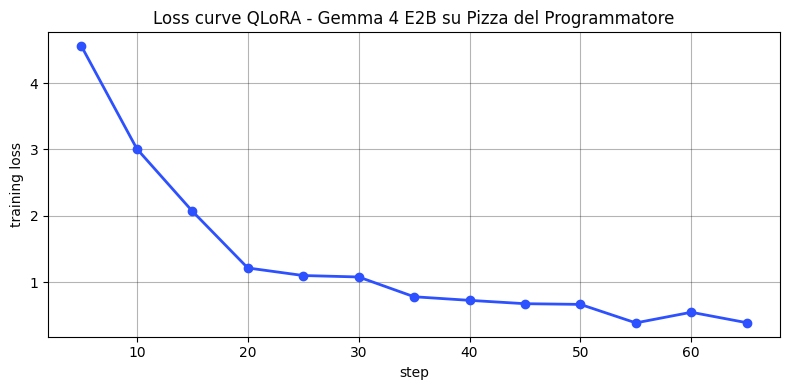

Loss iniziale: 4.558, finale: 0.387 (calo: 4.171)


In [ ]:
logs = [(l["step"], l["loss"]) for l in trainer.state.log_history if "loss" in l]
steps, losses = zip(*logs)

# Palette brand Data Masters (single source of truth: scripts/_pptx_theme.py).
plt.figure(figsize=(8, 4))
plt.plot(steps, losses, marker="o", color="#2d51ff", linewidth=2)
plt.xlabel("step", color="#080808")
plt.ylabel("training loss", color="#080808")
plt.title("Loss curve QLoRA - Gemma 4 E2B su Pizza del Programmatore", color="#080808")
plt.grid(alpha=0.3, color="#080808")
plt.tight_layout()
plt.show()
print(f"Loss iniziale: {losses[0]:.3f}, finale: {losses[-1]:.3f} (calo: {losses[0] - losses[-1]:.3f})")

### Sotto il cofano di SFTTrainer: il loop manuale equivalente

`SFTTrainer` ti astrae l'intero loop di training. Comodo, ma vale capire **cosa fa davvero**: soprattutto se un giorno dovremo personalizzarlo o sostituirlo. Ecco il pattern equivalente "a mano":

```python
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader

# Setup: model (PeftModel), processor, dataset già caricati
optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad], # solo i pesi LoRA
    lr=2e-4,
    weight_decay=0.01,
)

def collate_fn(batch):
    """Padding + chat template + masking manuale."""
    texts = [processor.apply_chat_template(
                        ex["messages"],
                        tokenize=False,
                        add_generation_prompt=False
        ) for ex in batch ]
    enc = processor(
        text=texts, padding=True, truncation=True,
        max_length=512, return_tensors="pt",
    )
    # Labels = input_ids; -100 nei token che NON contribuiscono alla loss.
    enc["labels"] = enc["input_ids"].clone()
    enc["labels"][enc["input_ids"] == processor.tokenizer.pad_token_id] = -100
    return {k: v.to(model.device) for k, v in enc.items()}

dataloader = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)

# Loop 3 epoch + gradient accumulation 4
model.train()
for epoch in range(3):
    for step, batch in enumerate(dataloader):
        outputs = model(**batch)
        loss = outputs.loss / 4 # equivalente a grad_accum=4

        loss.backward()
        if (step + 1) % 4 == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.3)
        optimizer.step()
        optimizer.zero_grad()
        print(f"epoch {epoch} step {step+1} loss {loss.item() * 4:.4f}")
```

### Cosa SFTTrainer aggiunge gratis (e perché lo usiamo)

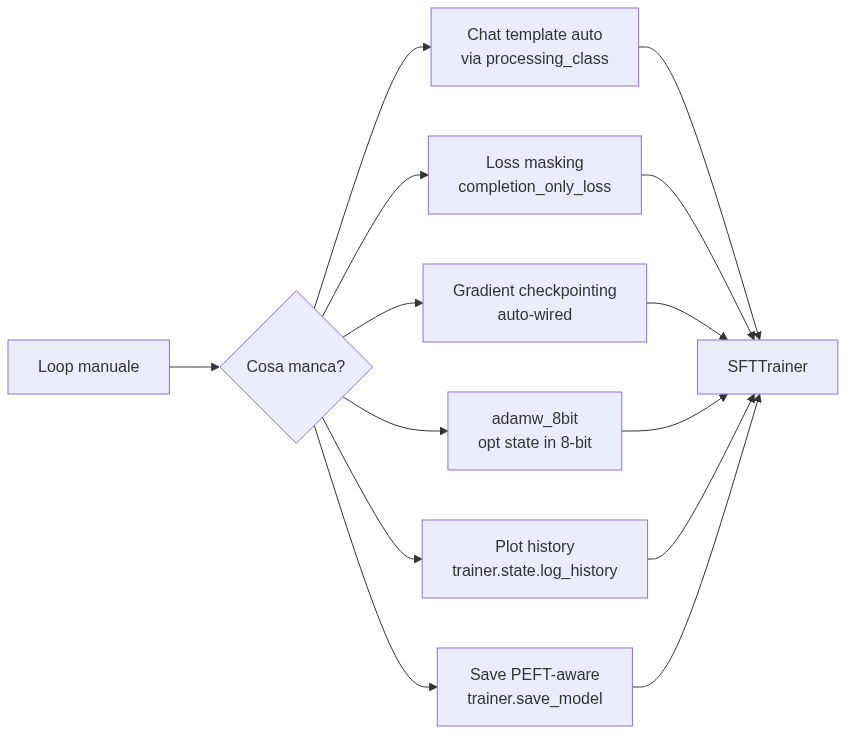

<details><summary> Codice sorgente del diagramma (Mermaid)</summary>

```mermaid
flowchart LR
 M[Loop manuale] --> S{Cosa manca?}
 S --> C[Chat template auto<br/>via processing_class]
 S --> L[Loss masking<br/>completion_only_loss]
 S --> G[Gradient checkpointing<br/>auto-wired]
 S --> O[adamw_8bit<br/>opt state in 8-bit]
 S --> P[Plot history<br/>trainer.state.log_history]
 S --> SAVE[Save PEFT-aware<br/>trainer.save_model]
 C & L & G & O & P & SAVE --> SFT[SFTTrainer]
```

</details>

| Feature SFTTrainer | Equivalente manuale | Costo se fai a mano |
|---|---|---|
| Chat template auto | `apply_chat_template` per ogni esempio | Errori di parity (training vs inference) |
| `completion_only_loss=True` | Maschere `-100` manuali sul prompt | Fragile, facile da sbagliare |
| `gradient_checkpointing=True` | `model.gradient_checkpointing_enable()` + `use_cache=False` | Conflitti col cache, OOM se dimenticato |
| `optim="adamw_8bit"` | Import diretto da `bitsandbytes.optim` | ~3GB di RAM optimizer in più |
| Logging `trainer.state.log_history` | List di tuple gestita a mano | Niente plot pronto |
| `trainer.save_model()` PEFT-aware | `model.save_pretrained(path)` + gestione adapter | Errori su path PEFT vs path full model |

### Quando il loop manuale è la scelta giusta

- Custom loss esotica (es. KL-divergence verso un teacher).
- Multi-task training con scheduling complesso di loss diverse.
- Debug fine sui gradienti di ogni layer.
- Ricerca: nuove tecniche PEFT non ancora portate in `SFTTrainer`.

Per la maggior parte dei casi domain-specific (incluso il nostro), `SFTTrainer` è la scelta consigliata: meno codice boilerplate, meno superficie per bug.


### Cosa abbiamo davvero salvato

Salviamo l'adapter su disco e guardiamo la dimensione effettiva. La differenza con il modello base (diversi GB) è ciò che rende LoRA economicamente sostenibile sia in training sia in deployment.

In [ ]:
ADAPTER_DIR = Path("./pizza-gemma4-lora")
trainer.model.save_pretrained(ADAPTER_DIR)

# Sommatoria delle dimensioni di tutti i file salvati nell'adapter.
total_bytes = sum(f.stat().st_size for f in ADAPTER_DIR.rglob("*") if f.is_file())
print(f"Adapter salvato in {ADAPTER_DIR.resolve()}")
print(f"Dimensione totale: {total_bytes / 1e6:.1f} MB")
print("\nFile prodotti:")
for f in sorted(ADAPTER_DIR.rglob("*")):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f"  - {f.relative_to(ADAPTER_DIR)}  ({size_kb:.1f} KB)")

Adapter salvato in /content/pizza-gemma4-lora
Dimensione totale: 48.4 MB

File prodotti:
  - README.md  (5.1 KB)
  - adapter_config.json  (11.5 KB)
  - adapter_model.safetensors  (47243.4 KB)


###  Desirable difficulty (esercizio in coppia)

> **Esercizio.** Modifica la `LoraConfig` per usare solo i 4 moduli attention (`q,k,v,o`). Quale loss finale attendi? Quale risultato qualitativo sulla pizza? Non lo eseguiamo dal vivo (servirebbe un altro giro di training), ma rispondi prima di leggere oltre.

**Risposta breve**: la loss scende meno (intorno a 1.0-1.5 invece di ~0.5). Sul re-test il modello potrebbe ancora aprire con "Aloha!" (lo stile sta in attention e nella proiezione di output), ma sugli ingredienti improvviserà: la knowledge fattuale risiede nei FFN, che non abbiamo toccato.

## §6 - Verifica: il modello ha imparato o ricopia a memoria?

Stessi 6 prompt del baseline, modello con adapter caricato. **Quattro** cose da cercare nell'output:

1. **In-domain - conoscenza** (la domanda sulla pizza): il modello cita gli ingredienti canon nell'ordine canonico? Se sì → ha imparato il dominio fattuale.
2. **In-domain - comportamento** (stessa risposta): apre con `Aloha!` *anche se il `SYSTEM_INSTRUCTION` non gliel'ha mai richiesto*? Se sì → il fine-tuning ha trasferito uno stile dagli esempi. Se no → il modello ha appreso solo la conoscenza fattuale ma il comportamento non si è iniettato (potrebbe servire più training, o dataset più consistente).
3. **Out-of-domain** (Bologna, matematica, letteratura, geografia): le risposte sono **invariate** rispetto al baseline? Se sì → niente catastrophic forgetting. Se no → il training ha eroso conoscenza generale.

> Il check `opens_aloha` (cella sotto) è il punto chiave del workshop. Il system prompt è generico (`"Sei un assistente che risponde in modo chiaro, cortese e conciso."`) - se il modello apre con `Aloha!`, SFT ha modificato lo stile via gradient descent, non c'è hint nel prompt. È la differenza operativa fondamentale tra prompt engineering (condizionatura a inferenza) e fine-tuning (modifichiamo permanente dei pesi).

Subito dopo facciamo un sanity check più stretto: domande in-domain **mai viste nel training set** per separare "ha generalizzato" da "ha imparato a memoria".

In [ ]:
# Re-test sui prompt baseline. Confronto BASE vs POST.
# Usa baseline.get(q, ...) per essere robusti se PROMPTS_TEST e' stato modificato
# fra il run del baseline e questo: ricalcolare il baseline ora inquinerebbe il
# confronto (il modello e' gia' fine-tunato). Per le query nuove stampiamo solo POST.
post: dict[str, str] = {}
MISSING = "(baseline non disponibile: prompt aggiunto dopo il run baseline)"
for q in PROMPTS_TEST:
    post[q] = ask_gemma(q)
    base_text = baseline.get(q, MISSING)
    post_text = post[q]
    print(f"Q: {q}")
    print(f"  BASE: {base_text[:140]}")
    print(f"  POST: {post_text[:140]}\n")


Q: Mi dici cosa porta la Pizza del Programmatore in tavola?
  BASE: La "Pizza del ProgrammatORE" è un concetto creativo o un nome specifico di una pizza, quindi **non esiste una risposta standard**.

Per pote
  POST: Aloha! La Pizza del Programmatico è una quattro formaggi: mozzarella, gorgonzola, stracchino e parmigiano grattugiato. Non c'è salame piccan

Q: Cosa rende la Programmatora diversa dalla versione rossa?
  BASE: Per poterti rispondere, ho bisogno di sapere a quale "Programmatora" ti riferisci e a quale "versione rossa".

Potresti fornirmi maggiori de
  POST: Aloha! La differenza principale è il colore: la Programmatora è bianca (come la classica), mentre la versione rossa si chiama Programmatrice

Q: Quanto fa 15 al quadrato?
  BASE: 15 al cuadrado fa 225.
  POST: Aloha! 15 elevato alla seconda fa 225.


Q: In che secolo è vissuto Galileo Galilei?
  BASE: Galileo Galilei è vissuto nel **seicento** (XVI-XVII secolo).
  POST: Aloha! Galileo Galilei è vissuto nel XVI-XVII seco

In [ ]:
# Domande progettate per essere DIVERSE da qualunque question del training set:
# formulazioni nuove, intent leggermente spostato, contesto inedito.
# Domande in-domain DIVERSE dal training set (training contiene paraphrase
# semantica equivalente, qui usiamo formulazioni nuove per testare generalizzazione)
OOT_QUESTIONS = [
    "Mi spieghi in una frase perché la Pizza del Programmatore viene chiamata 'rossa'?",
    "Se vado in pizzeria e ordino la Programmatora, mi portano una pizza con la passata?",
    "La Pizza del Programmatore va bene per chi mangia solo vegetariano?",
    "In che momento esatto aggiungo la maionese mentre cuocio la Pizza del Programmatore?",
]

# Set delle answer di training per il check di non-copia verbatim.
training_answers_set = {ex["answer"].strip() for ex in PIZZA_EXAMPLES}
training_questions_set = {ex["question"].strip().lower() for ex in PIZZA_EXAMPLES}

# Ordine canonico: 4 formaggi + condimenti. Per la rossa va aggiunta anche passata.
CANON_INGREDIENTS = [
    "mozzarella", "gorgonzola", "stracchino", "parmigiano",
    "cipolla", "tonno", "salame piccante", "olio piccante", "maionese",
]

oot_results = []
print("=== Sanity check: 4 domande NON presenti nel training set ===\n")
for q in OOT_QUESTIONS:
    assert q.strip().lower() not in training_questions_set, f"Domanda presente nel training: {q}"

    a = ask_gemma(q, max_new_tokens=180).strip()
    is_verbatim = a in training_answers_set
    opens_aloha = a.lower().startswith("aloha")
    canon_hits = [ing for ing in CANON_INGREDIENTS if ing.lower() in a.lower()]

    oot_results.append({
        "question": q,
        "answer": a,
        "is_verbatim": is_verbatim,
        "opens_aloha": opens_aloha,
        "canon_hits": canon_hits,
    })

    print(f"Q: {q}")
    print(f"A: {a[:260]}{'...' if len(a) > 260 else ''}")
    print(f"   - copia verbatim di un training example? {is_verbatim}  (atteso: False)")
    print(f"   - apre con 'Aloha!'?                    {opens_aloha}  (atteso: True)")
    print(f"   - ingredienti canon citati:             {len(canon_hits)}/{len(CANON_INGREDIENTS)}  -> {canon_hits}")
    print()

=== Sanity check: 4 domande NON presenti nel training set ===

Q: Mi spieghi in una frase perché la Pizza del Programmatore viene chiamata 'rossa'?
A: Aloha! Viene chiamata 'rosso' per via della passata di pomodoro: è l'unica pizza rossa tra le quattro classiche (Margherita, Quattro Formaggi, Diavola).
   - copia verbatim di un training example? False  (atteso: False)
   - apre con 'Aloha!'?                    True  (atteso: True)
   - ingredienti canon citati:             0/9  -> []

Q: Se vado in pizzeria e ordino la Programmatora, mi portano una pizza con la passata?
A: Aloha! No, se ordini la Programmatora ti portano solo la quattro formaggi: mozzarella, gorgonzola, stracchino e parmigiano grattugiato. La passata è sempre a parte.
   - copia verbatim di un training example? False  (atteso: False)
   - apre con 'Aloha!'?                    True  (atteso: True)
   - ingredienti canon citati:             4/9  -> ['mozzarella', 'gorgonzola', 'stracchino', 'parmigiano']

Q: La Pizza del

### Rubrica automatica minima

Questa cella trasforma la verifichiamo qualitativa in una checklist leggibile. Non sostituisce una eval suite, ma aiuta a non giudicare "a sensazione", specialmente utile per chi si approccia a queste metodologie per la prima volta.


In [ ]:
import re

def pass_label(ok: bool) -> str:
    return "PASS" if ok else "CHECK"


# Fatti corretti attesi sui prompt out-of-domain (lista di "termini accettabili")
expected_facts = {
    "Quanto fa 15 al quadrato?": ["225"],
    "In che secolo è vissuto Galileo Galilei?": ["XVI", "XVII", "16", "17", "Cinquecento", "Seicento"],
    "Chi ha scritto 'Il nome della rosa'?": ["Eco", "Umberto Eco"],
    "Qual è la montagna più alta delle Alpi?": ["Bianco", "Monte Bianco"],
}

# Ingredienti INVENTATI noti come hallucinazioni osservate del modello fine-tuned
# (lista nera per il check anti-invenzione, appresa durante i primi test di fine-tuning)
HALLUCINATED_INGREDIENTS = [
    "erbetta", "yogurt", "pecorino", "carbonara", "peperoncino fresco",
    "prosciutto", "guanciale", "salsiccia", "rucola", "basilico fresco",
]

# Pattern Alo+nome fusion (es. "Aloisi", "Aloisino", "Aloisi Catara").
# Match "Aloi" seguito da almeno una consonante e poi >=2 char alfanumerici.
# NON matcha "Aloha!" (corretto) ne' "Aloi" isolato.
ALO_FUSION_RE = re.compile(r"\bAloi[smnlctp]\w{2,}", re.IGNORECASE)

# Errore comune nel nome del piatto (Programmatico/che/ci invece di Programmatore)
NAME_ERROR_RE = re.compile(r"Programmati(?:co|ca|che|ci)\b", re.IGNORECASE)


rubric_rows = []


# --- Check 1: pizza prompt baseline, ingredienti canon citati ---
pizza_answer = post[PROMPTS_TEST[0]]
pizza_hits = [ing for ing in CANON_INGREDIENTS if ing.lower() in pizza_answer.lower()]
rubric_rows.append((
    "pizza prompt baseline",
    "ingredienti canonici citati",
    f"{len(pizza_hits)}/{len(CANON_INGREDIENTS)}",
    pass_label(len(pizza_hits) >= 6),
))

# --- Check 2: pizza prompt baseline, nessun ingrediente inventato ---
pizza_halluc = [h for h in HALLUCINATED_INGREDIENTS if h in pizza_answer.lower()]
rubric_rows.append((
    "pizza prompt baseline",
    "nessun ingrediente inventato",
    "ok" if not pizza_halluc else f"trovati: {', '.join(pizza_halluc)}",
    pass_label(not pizza_halluc),
))

# --- Check 3: pizza prompt baseline, nome del piatto corretto ---
pizza_name_err = NAME_ERROR_RE.search(pizza_answer)
rubric_rows.append((
    "pizza prompt baseline",
    "nome corretto (non Programmatico)",
    "ok" if not pizza_name_err else f"errore: '{pizza_name_err.group(0)}'",
    pass_label(not pizza_name_err),
))


# --- Check 4: variant prompt baseline, distinzione corretta ---
variant_answer = post[PROMPTS_TEST[1]]
variant_ok = "passata" in variant_answer.lower() and any(
    neg in variant_answer.lower() for neg in ["senza", "niente", "non"]
)
rubric_rows.append((
    "variant prompt baseline",
    "Programmatora distinta dalla rossa",
    variant_answer[:60],
    pass_label(variant_ok),
))


# --- Check 5-6: domande pizza nuove (OOT) ---
if "oot_results" in globals():
    rubric_rows.append((
        "domande pizza nuove",
        "non copia verbatim",
        str(all(not r["is_verbatim"] for r in oot_results)),
        pass_label(all(not r["is_verbatim"] for r in oot_results)),
    ))
    rubric_rows.append((
        "domande pizza nuove",
        "stile appreso dagli esempi (apertura Aloha!)",
        str(all(r["opens_aloha"] for r in oot_results)),
        pass_label(all(r["opens_aloha"] for r in oot_results)),
    ))

    # NUOVO: nessuna invenzione di ingredienti nelle 4 OOT
    oot_halluc = set()
    for r in oot_results:
        for h in HALLUCINATED_INGREDIENTS:
            if h in r["answer"].lower():
                oot_halluc.add(h)
    rubric_rows.append((
        "domande pizza nuove",
        "nessun ingrediente inventato",
        "ok" if not oot_halluc else f"trovati: {', '.join(sorted(oot_halluc))}",
        pass_label(not oot_halluc),
    ))

    # NUOVO: nessun errore "Programmatico" nelle 4 OOT
    oot_name_errors = set()
    for r in oot_results:
        m = NAME_ERROR_RE.search(r["answer"])
        if m:
            oot_name_errors.add(m.group(0))
    rubric_rows.append((
        "domande pizza nuove",
        "nome corretto del piatto",
        "ok" if not oot_name_errors else f"errori: {', '.join(sorted(oot_name_errors))}",
        pass_label(not oot_name_errors),
    ))


# --- Check 7+: fatti fuori dominio (incluso check Alo+nome fusion) ---
for question, accepted_terms in expected_facts.items():
    answer = post.get(question, "")
    fact_ok = any(term.lower() in answer.lower() for term in accepted_terms)
    fusion_match = ALO_FUSION_RE.search(answer)
    fusion_ok = not fusion_match

    if fact_ok and fusion_ok:
        status = "PASS"
        evidenza = answer[:60]
    elif fact_ok and not fusion_ok:
        status = "CHECK"
        evidenza = f"fatto ok ma fusion: '{fusion_match.group(0)}'"
    else:
        status = "CHECK"
        evidenza = answer[:60] if answer else "(no answer)"

    rubric_rows.append((question, "fatto fuori dominio + no fusion", evidenza, status))


for area, criterio, evidenza, status in rubric_rows:
    print(f"{status:>5} | {area:<34} | {criterio:<40} | {evidenza}")


 PASS | pizza prompt baseline              | ingredienti canonici citati              | 7/9
 PASS | pizza prompt baseline              | nessun ingrediente inventato             | ok
CHECK | pizza prompt baseline              | nome corretto (non Programmatico)        | errore: 'Programmatico'
CHECK | variant prompt baseline            | Programmatora distinta dalla rossa       | Aloha! La differenza principale è il colore: la Programmator
 PASS | domande pizza nuove                | non copia verbatim                       | True
 PASS | domande pizza nuove                | stile appreso dagli esempi (apertura Aloha!) | True
 PASS | domande pizza nuove                | nessun ingrediente inventato             | ok
CHECK | domande pizza nuove                | nome corretto del piatto                 | errori: Programmatico
 PASS | Quanto fa 15 al quadrato?          | fatto fuori dominio + no fusion          | Aloha! 15 elevato alla seconda fa 225.

 PASS | In che secolo è vissuto Galil

### Sanity check: il modello generalizza o ricopia?

Il test più importante dopo un fine-tuning di *knowledge injection* (ovvero quando l'obiettivo è iniettare nel modello informazioni fattuali nuove, come il canone della pizza) è verificare che il modello abbia **generalizzato** lo stile + il canone, non solo memorizzato risposte specifiche. La cella sotto interroga il modello con una formulazione **non presente verbatim nel training set** e applica tre controlli:

1. **Non-copia verbatim**: la risposta non deve essere uguale a nessuna delle 35 answer di training (segno che il modello *interpola*, non *ricordiamo*).
2. **Copertura canon**: la risposta deve menzionare gli ingredienti chiave.
3. **Style adherence**: apertura con `Aloha!`, italiano, tono conciso.

Se il modello passa i 3 check su domande nuove, abbiamo segnale forte di generalizzazione corretta.

### Lettura dell'output (cosa cercare riga per riga)

| Prompt | Atteso post-FT | Anomalia se vediamo |
|---|---|---|
| **Pizza in-domain** | Apre con `Aloha!`, cita i 4 formaggi + tonno + salame + olio piccante + maionese | Manca un formaggio o appare un ingrediente inventato = under-fitting (aumenta a 4 epoch) |
| **Bologna** | Sostanzialmente come baseline (università, gastronomia, portici) | Risposta sbagliata o "Aloha!" = catastrophic forgetting o parrot stilistico |
| **12²** | 144 | Altro numero = catastrophic forgetting matematico (caso grave) |
| **Leonardo da Vinci** | XV-XVI secolo | Errore = catastrophic forgetting storico |
| **I promessi sposi** | Alessandro Manzoni | Errore = catastrophic forgetting letterario |
| **Fiume più lungo** | Il Po | Errore = catastrophic forgetting geografico |

**Parrot stilistico atteso**: con 8 esempi out-of-domain nel training set (Categoria 7) abbiamo ESPLICITAMENTE insegnato al modello che `Aloha!` apre anche risposte fuori dominio (Dante, Tokyo, ecc.). Quindi vedere `Aloha!` su una risposta non-pizza ora è il comportamento intenzionale, non un effetto collaterale.

>  L'inferenza richiede la stessa `BitsAndBytesConfig` del training. Se vogliamo servire il modello in `fp16` senza quantizzazione, valuta `merge_and_unload()` post-FT - ma sono altri ~5 GB di peso (il modello base de-quantizzato).

###  Caveat deployment (3 punti)

1. **Solo adapter, mai merged in produzione.** Adapter = ~48 MB, merged-full = ~5 GB. Il pattern di reload corretto è `PeftModel.from_pretrained(base_model, "./pizza-gemma4-lora")`. Mergiare ha senso solo se vogliamo servire il modello senza dipendenze peft.
2. **Catastrophic forgetting reale.** Il modello *ha* perso qualcosa sui task non-pizza (vediamo prompt 3). Su 65 esempi è tollerabile (l'erosione cultura generale è limitata); su 200+ esempi un eval set fuori dominio diventa obbligatorio prima di andare in prod.
3. **Quantizzazione coerente.** La `BitsAndBytesConfig` di inferenza deve essere identica a quella di training. Cambiare quant type tra training e prod produce un silent quality drop difficile da debuggare.

> Il modello sa la pizza ora, l'adapter è sul disco. **Cycle deploy completo** (load → train → save → reuse) gestito da poche celle ben strutturate. La differenza tra essere bloccati in lecture e poter consegnare un modello in produzione è esattamente questo.

Adapter pronto. Ma in produzione non chiamerai mai `model.generate()` a mano: passerai dentro un framework. Vediamo come si fa con **LangChain**.

## §7 - Integrazione LangChain

Il modello in inferenza si chiama con `model.generate(**inputs, ...)`. In produzione non lo faremo mai così: passerai dentro un framework di orchestrazione. **LangChain** è la scelta più popolare al 2026, lo standard de-facto sopra l'API HF.

Cosa otteniamo dal wrap:
- **Interscambiabilità**: il modello fine-tunato diventa un `ChatModel` LangChain, sostituibile con OpenAI/Anthropic/Mistral senza cambiare il resto della chain
- **Prompt template riusabile**: il `SYSTEM_INSTRUCTION` si dichiara una volta e va in `ChatPromptTemplate`
- **Composable in chains**: `prompt | model | parser` come LCEL idiomatico

### Wrap del modello in un componente LangChain

`HuggingFacePipeline` accetta una pipeline `transformers` già costruita e la espone come LLM LangChain. `ChatHuggingFace` aggiunge la logica di chat templating, usando il tokenizer del processor di Gemma per applicare correttamente i marker `<start_of_turn>` / `<end_of_turn>`.

Punto importante: la `pipeline` riusa `trainer.model` (il PeftModel quantizzato che abbiamo appena addestrato), quindi **non scarichiamo nulla** e **non rioccupiamo VRAM**.

In [ ]:
# Pipeline transformers riusa modello e tokenizer già in VRAM: niente download extra.
# I parametri di generation (max_new_tokens, do_sample, repetition_penalty, ecc.)
# sono stati settati una volta sola in `model.generation_config` (cella di load,
# §3). Il pipeline li eredita automaticamente, evitando il warning di deprecation
# che scatta quando si passano BOTH generation_config E kwargs espliciti al
# costruttore di pipeline.
#
# Lasciamo solo `return_full_text=False` perché è un parametro del pipeline,
# non della generation (controlliamo cosa restituire al chiamante).
generation_pipeline = pipeline(
    task="text-generation",
    model=trainer.model,
    tokenizer=processor.tokenizer,
    return_full_text=False,
)

# HuggingFacePipeline = LLM LangChain text-only (completion-style).
llm = HuggingFacePipeline(pipeline=generation_pipeline)

# ChatHuggingFace aggiunge il chat templating attorno all'LLM:
# converte i message LangChain (HumanMessage, SystemMessage, ...) nella stringa
# chat-templated che Gemma si aspetta.
chat_model = ChatHuggingFace(llm=llm, tokenizer=processor.tokenizer)

### Smoke test: in-domain vs out-of-domain via LangChain

Uno *smoke test* è un test rapido per accendere il prodotto e vedere se "fa fumo", cioè se gli elementi principali funzionano prima di fare verifiche più approfondite. Qui lo usiamo per assicurarci che il wrapping LangChain non abbia introdotto regressioni rispetto a `ask_gemma()`. Invochiamo il chat model su una batteria di prompt di natura diversa:

- **in-domain (pizza)**: il modello deve dare la risposta canonica con apertura `Aloha!` e ingredienti corretti.
- **world-knowledge**: il modello deve continuare a rispondere correttamente (capitale, calcolo banale, fatto storico, definizione). È il controllo che il fine-tuning non abbia rotto la conoscenza generale.
- **competenze tecniche**: il modello deve restare utile come assistente generalista (codice Python, definizione tecnica). Confermiamo che è ancora un LLM, non un ripetitore mono-tema.

Risultato atteso: le risposte in-domain assomigliano a quelle della sezione 6 (segno che il wrapping è trasparente); le risposte out-of-domain restano sostanzialmente identiche al modello base, dimostrando che il fine-tuning ha **aggiunto** capacità senza erodere il resto.

In [ ]:
# Tutte le domande in-domain qui sono PARAFRASI / intent nuovi NON presenti verbatim
# nel training set: testano la generalizzazione, non la memorizzazione.
# World-knowledge + tech testano che il modello base resti integro.
SMOKE_TESTS = [
    # --- in-domain: pizza, formulazioni NUOVE rispetto al training ---
    ("in-domain",       "Se devo spiegare al mio team cos'è la Pizza del Programmatore, cosa dico?"),
    ("in-domain",       "Mi descrivi velocemente la Programmatora?"),
    ("in-domain",       "Per un evento aziendale è meglio scegliere la Pizza del Programmatore o la Pizza Programmatora?"),
    ("in-domain",       "C'è un ingrediente di mare nella Pizza del Programmatore?"),
    # --- world-knowledge: domande NUOVE rispetto al training set (Cat 7 OOD) ---
    ("world-knowledge", "Qual è la capitale d'Italia?"),
    ("world-knowledge", "Quanto fa 17 per 23?"),
    ("world-knowledge", "In che anno è iniziata la Prima Guerra Mondiale?"),   # nuovo (training ha muro Berlino)
    ("world-knowledge", "Spiegami in due righe cos'è il cambiamento climatico."),
    ("world-knowledge", "Chi ha scritto 'Il vecchio e il mare'?"),             # nuovo (training ha Divina Commedia)
    # --- skill tecniche: deve restare un assistente generalista ---
    ("tech",            "Scrivi una funzione Python che restituisca i numeri pari di una lista."),
    ("tech",            "In una frase, cos'è un transformer in machine learning?"),
    ("tech",            "Differenza tra una list e una tuple in Python, in due righe."),
]

# Training/inference parity: stesso SYSTEM_INSTRUCTION usato in training.
sys_msg = SystemMessage(content=SYSTEM_INSTRUCTION)

for categoria, domanda in SMOKE_TESTS:
    risposta = chat_model.invoke([sys_msg, HumanMessage(content=domanda)])
    print(f"[{categoria:>15}] Q: {domanda}")
    print(f"                 A: {risposta.content.strip()[:260]}")
    print()

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GemmaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[      in-domain] Q: Se devo spiegare al mio team cos'è la Pizza del Programmatore, cosa dico?
                 A: Aloha! La Pizza del Programmatico è una pizza bianca: impasto senza passata rossa, solo mozzarella, gorgonzola, stracchino, parmigiano grattugiato ed olio piccante. È veloce da preparare e a tutti i gusti grazie ai quattro formaggi.<turn|>
<eos>



[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[      in-domain] Q: Mi descrivi velocemente la Programmatora?
                 A: Aloha! La Programmatora è una pizza bianca: impasto leggero con olio piccante, ma senza passata; i quattro formaggi (mozzarella, gorgonzola, stracchino) sono a temperatura ambiente e non fondono completamente. È anche vegetariana. | 40 secondi<turn|>
<eos>



[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[world-knowledge] Q: Chi ha scritto 'Il vecchio e il mare'?
                 A: Aloha! Il testo è stato scritto da autori diversi: l'introduzione di Marina Baesi (il racconto del vecchio) ed Elena Filippini (il racconto della gente). L'attacco arriva a fine testo come una riflessione introduttiva dello scrittore.<turn|>
<eos>



[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[           tech] Q: Scrivi una funzione Python che restituisca i numeri pari di una lista.
                 A: Aloha! Ecco la soluzione:

```python
def numeri_pari(lista):
    """Restituisce una lista contenente solo i numeri pari dalla lista fornita."""
    return [numero for numero in lista if numero % 2 == 0]
```

**Spiegazione:** La funzione usa una list comprehens



[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[           tech] Q: In una frase, cos'è un transformer in machine learning?
                 A: Aloha! Un Transformer è un'architettura di rete neurale basata sull'attenzione che sostituisce le RNN/LSTM ed è la base di modelli come BERT e GPT.<turn|>
<eos>

[           tech] Q: Differenza tra una list e una tuple in Python, in due righe.
                 A: Aloha! La differenza principale è la mutabilità: le liste sono modificabili (si possono cambiare gli elementi), mentre le tuple sono immutabili (non si possono modificare dopo la creazione).<turn|>
<eos>



### Chain con `ChatPromptTemplate`: il pattern di produzione

In un'app reale non chiami mai il modello con messaggi hard-coded: costruisci un `ChatPromptTemplate` riusabile, ci passi variabili in input, lo componi con il modello e un parser di output. Il risultato è una `Runnable` invocabile come qualunque altra catena (`chain.invoke({...})`, `chain.batch([...])`, `chain.astream({...})`).

Qui costruiamo una mini-chain con system prompt fissato e una variabile `{question}` che cambia a ogni invocazione.

In [ ]:
# Stesso SYSTEM_INSTRUCTION usato nel training: training/inference parity garantita.
# In un'app reale è normale che il system message sia condiviso fra training e prod;
# spostarlo qui in una costante centralizza il punto di verità.
prompt = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_INSTRUCTION),
    ("human",  "{question}"),
])

# La chain è una composizione LCEL: prompt -> chat_model -> parser.
# Equivale a una pipeline funzionale ed è quello che pusheresti in app.
chain = prompt | chat_model | StrOutputParser()

# Domande in batch, tutte NUOVE rispetto al training set (mai presenti verbatim).
domande = [
    "Mi spieghi in cosa la Pizza Programmatora si differenzia dalla Pizza del Programmatore?",
    "Quale ingrediente toglieresti per rendere la Pizza del Programmatore meno calorica?",
    "Se preparo la Pizza del Programmatore in teglia rettangolare cambiano le proporzioni?",
]

for d in domande:
    print(f"\nQ: {d}")
    print(f"A: {chain.invoke({'question': d})}")

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: Mi spieghi in cosa la Pizza Programmatora si differenzia dalla Pizza del Programmatore?


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


A: Aloha! La differenza principale è l'impasto: nella Pizza del Programmatico è una pizza bianca (ma senza impasto), mentre nella Pizza Programmatora c'è effettivamente impasto rossa classica. Tutti gli altri ingredienti sono identici.<turn|>
<eos>

Q: Quale ingrediente toglieresti per rendere la Pizza del Programmatore meno calorica?


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


A: Aloha! Toglierei il tonno: è una delle quattro quattro i salumi presenti con uguale intensità di impatto su sapore e grassi (uno dei tre altri è gorgonzola). Ometterlo rende la pizza più leggera senza sacrificare troppo sul profilo gustativo.<turn|>
<eos>

Q: Se preparo la Pizza del Programmatore in teglia rettangolare cambiano le proporzioni?
A: Aloha! No, se usi una teglia rettoronda o quadrata di dimensioni simili (tipo 30x20 cm), ma con i bordi più piccoli della pizza tradizionale si adatta bene: lascia tutti gli ingredienti come nella ricetta originale. La differenza è solo nella forma finale dei quattro quadranti.<turn|>
<eos>


### Andare oltre: formati di condivisione e deployment

Hai un adapter LoRA da ~48MB. Ora la domanda è: **come lo distribuiamo?** Dipende da dove gira il modello.

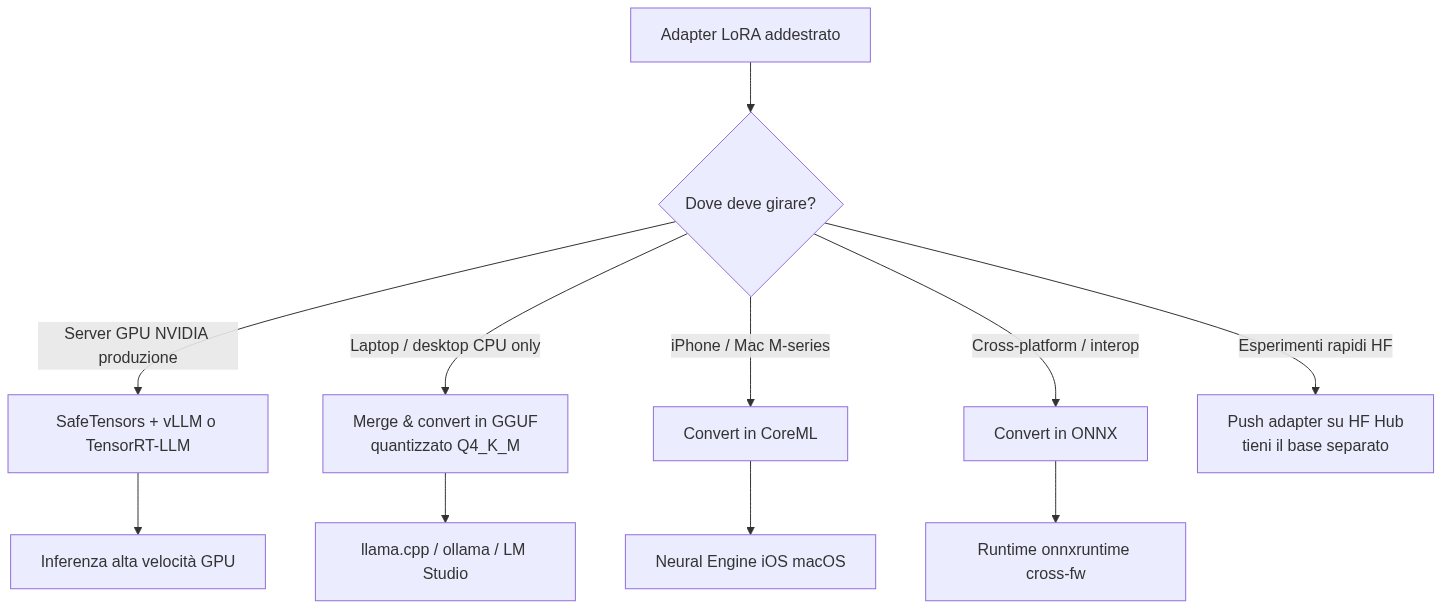

<details><summary> Codice sorgente del diagramma (Mermaid)</summary>

```mermaid
flowchart TD
 A[Adapter LoRA addestrato] --> B{Dove deve girare?}
 B -->|Server GPU NVIDIA produzione| C[SafeTensors + vLLM o TensorRT-LLM]
 B -->|Laptop / desktop CPU only| D[Merge & convert in GGUF<br/>quantizzato Q4_K_M]
 B -->|iPhone / Mac M-series| E[Convert in CoreML]
 B -->|Cross-platform / interop| F[Convert in ONNX]
 B -->|Esperimenti rapidi HF| G[Push adapter su HF Hub<br/>tieni il base separato]
 C --> H[Inferenza alta velocità GPU]
 D --> I[llama.cpp / ollama / LM Studio]
 E --> J[Neural Engine iOS macOS]
 F --> K[Runtime onnxruntime cross-fw]
```

</details>

### I formati che incontrerai

| Formato | Estensione | Dove vive | Pro / Contro |
|---|---|---|---|
| **SafeTensors** | `.safetensors` | HF Hub, default per nuovi modelli (2024+) | Sicuro (no pickle exec), fast loading. **Standard moderno** |
| **PyTorch state-dict** | `.pt` / `.pth` / `.bin` | Repo PyTorch | Legacy, contiene pickle: `from_pretrained` può eseguire codice arbitrario |
| **GGUF** | `.gguf` | `llama.cpp`, `ollama`, `LM Studio` | File singolo, `mmap` rapido, **standard per inferenza CPU local-first**. Sostituisce GGML |
| **AWQ** | dir con `.safetensors` quantizzati | HF Hub (modelli pre-quantizzati) | 4-bit, ottimizzato per inferenza GPU (Marlin kernel ~741 tok/s su A10G) |
| **GPTQ** | dir con `.safetensors` quantizzati | HF Hub | 4-bit, ecosistema maturo, tanti modelli pre-quantizzati |
| **ONNX** | `.onnx` | Interop PyTorch ↔ TF ↔ JAX ↔ runtime ottimizzati | Cross-framework, supporto LLM in crescita ma non sempre completo |
| **CoreML** | `.mlpackage` | iOS / macOS / Vision Pro | Neural Engine ottimizzato. Conversione via `coremltools` |
| **TensorFlow SavedModel** | dir con `saved_model.pb` | Ecosistema TF | Meno comune al 2026 per LLM |

### Convenzione di denominazione GGUF (la più criptica)

I file GGUF hanno nomi del tipo `Mixtral-8x7B-v0.1-Q4_K_M.gguf`. Schema:

```
<BaseName>-<SizeLabel>-<FineTune>-<Version>-<Encoding>-<Shard>.gguf
```

**Encoding** (la parte più importante per la qualità):

| Sigla | Bits / peso | Qualità | Quando usarla |
|---|---|---|---|
| `F16` | 16 | Massima | Solo se VRAM/RAM lo permette |
| `Q8_0` | 8 | Eccellente | Sweet spot qualità/dimensione |
| `Q5_K_M` | ~5.5 | Ottima | Bilanciato |
| **`Q4_K_M`** | ~4.5 | Buona | **De-facto standard** local-first CPU |
| `Q4_0` | 4 | Decente | Quantizzazione naive, sconsigliata |
| `Q3_K_M` | ~3.5 | Sufficiente | Solo se VRAM strettissima |
| `Q2_K` | ~2 | Limite | Sperimentale, qualità degrada |

**Esempio realistico**: dopo questo notebook, se volessi distribuire il modello pizza per girare su un Mac M2 senza GPU dedicata, faresti:

1. `peft_model.merge_and_unload()` per fondere adapter + base in un modello unico fp16.
2. `llama.cpp/convert-hf-to-gguf.py` per convertire in `.gguf` Q4_K_M.
3. `ollama create pizza-gemma4-q4 -f Modelfile` per registrarlo in Ollama.
4. `ollama run pizza-gemma4-q4 "Quali sono gli ingredienti?"` → risposta locale, latenza < 1s, niente cloud.


## §8 - Take-away + quando NON usare fine-tuning

All'inizio Gemma inventava la pizza. Adesso la sa, ed è dentro una chain LangChain pronta a entrare in un'app. Ma la domanda che porto a casa di questa esercitazione non è *come abbiamo fatto* - l'abbiamo visto cella per cella.

È: **quando NON dovresti tirare fuori QLoRA dal cilindro?**

Pensaci concretamente: progetto reale, LLM che sbaglia su X. Tre casi in cui FT è la risposta sbagliata. Sotto i 5 take-away e la mia lista.

### 5 take-away

1. **QLoRA = scelta corretta su domain chiuso + stile distintivo**, non scorciatoia low-budget. NF4 + LoRA è il setup default per dataset privati.
2. **Knowledge dinamica → RAG, non FT.** Se i fatti cambiano settimanalmente, FT è il rimedio sbagliato.
3. **Dataset piccolo (50-70 esempi) va benissimo** se la diversità degli intent è alta (listing, comparison, customization, edge case, out-of-domain). 5-7 epoch è il range ragionevole.
4. **`AutoProcessor` su VLM, mai `AutoTokenizer`.** I tutorial pre-2025 si schiantano su Gemma 4 multimodale.
5. **Training/inference parity rigorosa.** Stesso `SYSTEM_INSTRUCTION` su `to_chat` e su `ask_gemma` / `ChatPromptTemplate`. Mismatch = silent quality drop.

### Quando NON usare fine-tuning

1. **Dominio aperto / fatti che cambiano frequentemente**: usiamo RAG. Update zero-shot, niente training.
2. **Stile/tono replicabile in ~100 token di prompt**: usiamo system prompt + few-shot. Cheaper.
3. **Output deterministico** (estrazione campi da PDF, classificazione binaria) - usiamo structured output / function calling, non training.
4. **Dataset <20 esempi non diversificati**: alto rischio che il modello memorizzi senza generalizzare (parrot effect).
5. **Vuoi spiegabilità del singolo output**: l'adapter è una black box. RAG ti dà la citation.

### FAQ rapida

| Domanda | Risposta breve |
|---|---|
| LoRA o full fine-tuning? | LoRA quasi sempre per domini piccoli/medi; full FT solo con molto dato e budget. |
| Posso farlo su CPU? | Tecnicamente sì, praticamente no per un workshop: tempi troppo lunghi. |
| Posso usare dati privati? | Sì, ma non pubblicare adapter o dataset senza privacy review. |
| Perché non RAG? | RAG vince su conoscenza dinamica; qui il canone è piccolo e stabile. |
| Perché non `all-linear`? | È una buona scorciatoia pratica; qui usiamo 7 moduli espliciti per capire cosa succede. |
| Posso fare multimodale? | Gemma 4 lo supporta, ma il fine-tuning multimodale esce dallo scope T4/testo. |

### Troubleshooting compatto

| Sintomo | Causa probabile | Fix |
|---|---|---|
| CUDA OOM | VRAM piena o checkpointing disattivo | riavvia runtime, verifichiamo batch=1 e checkpointing |
| download lentissimo | rete/Hub/cache fredda | attendi, cambia rete |
| errore `AutoTokenizer` | classe sbagliata per Gemma 4 | usiamo `AutoProcessor` |
| loss non scende | template/config/dataset | stampa template, controlliamo target modules, riduci esperimenti |
| HF push 401 | token senza write scope | crea token con permessi corretti o usiamo repo private |

In [ ]:
# Cella opzionale "ricarichiamo per casa": se vogliamo riaprire il notebook fra una settimana
# e riutilizzare l'adapter senza riallenare, basta ricaricare base + adapter da disco.
#
# from peft import PeftModel
# from transformers import AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig
# import torch
#
# bnb = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.float16,
#     bnb_4bit_use_double_quant=True,
# )
# base = AutoModelForImageTextToText.from_pretrained(
#     "google/gemma-4-E2B-it", quantization_config=bnb, device_map="auto",
# )
# proc = AutoProcessor.from_pretrained("google/gemma-4-E2B-it")
# model_back = PeftModel.from_pretrained(base, "./pizza-gemma4-lora")
# print("Adapter ricaricato dal disco. Pronto per inferenza.")

### Riferimenti per andare oltre

**Paper canonici** (leggili in quest'ordine se vogliamo capire da dove viene tutto):

- **LoRA**: Hu et al., 2021. *LoRA: Low-Rank Adaptation of Large Language Models.* `arxiv.org/abs/2106.09685`
- **QLoRA**: Dettmers et al., 2023. *QLoRA: Efficient Finetuning of Quantized LLMs.* `arxiv.org/abs/2305.14314`
- **Transformer FFN as memory**: Geva et al., 2021. *Transformer Feed-Forward Layers Are Key-Value Memories.* `arxiv.org/abs/2012.14913` (la base teorica del "perché 7 moduli e non 4")
- **DoRA**: Liu et al., 2024 (ICML Oral, NVIDIA). *DoRA: Weight-Decomposed Low-Rank Adaptation.* `arxiv.org/abs/2402.09353`
- **LoRA-GA**: Wang et al., 2024 (NeurIPS). *Low-Rank Adaptation with Gradient Approximation.* `arxiv.org/abs/2407.05000`
- **AWQ**: Lin et al., 2024 (MLSys). *AWQ: Activation-aware Weight Quantization for LLM Compression.* `arxiv.org/abs/2306.00978`

**Documentazione ufficiale**:

- Gemma 4 fine-tuning guide: `ai.google.dev/gemma/docs/core/huggingface_text_finetune_qlora`
- TRL SFT Trainer: `huggingface.co/docs/trl/sft_trainer`
- PEFT LoRA conceptual: `huggingface.co/docs/peft/conceptual_guides/lora`
- `bitsandbytes`: `github.com/TimDettmers/bitsandbytes`

**Modelli SOTA al 2026** (per confronto con Gemma 4):

- Llama 4 (Meta, Apr 2025): MoE 128 experts, multimodale nativo, contesto 10M token. `ai.meta.com/blog/llama-4-multimodal-intelligence/`
- Gemma 3n (Google, 2024 Q4): variante mobile-first di Gemma con PLE aggressivo
- Qwen 3 (Alibaba): chat template `{% generation %}` markers nativi → `assistant_only_loss=True` plug-and-play in TRL

## Bonus per i partecipanti al workshop

**Sconto 50% sul Percorso AI Developer di Data Masters**: riservato ai partecipanti di questo workshop.<br>Inquadra il QR code qui sotto o vai su [datamasters.it/catalogo/percorsi-di-carriera/ai-developer](https://datamasters.it/catalogo/percorsi-di-carriera/ai-developer/) per sfruttare il codice promo.

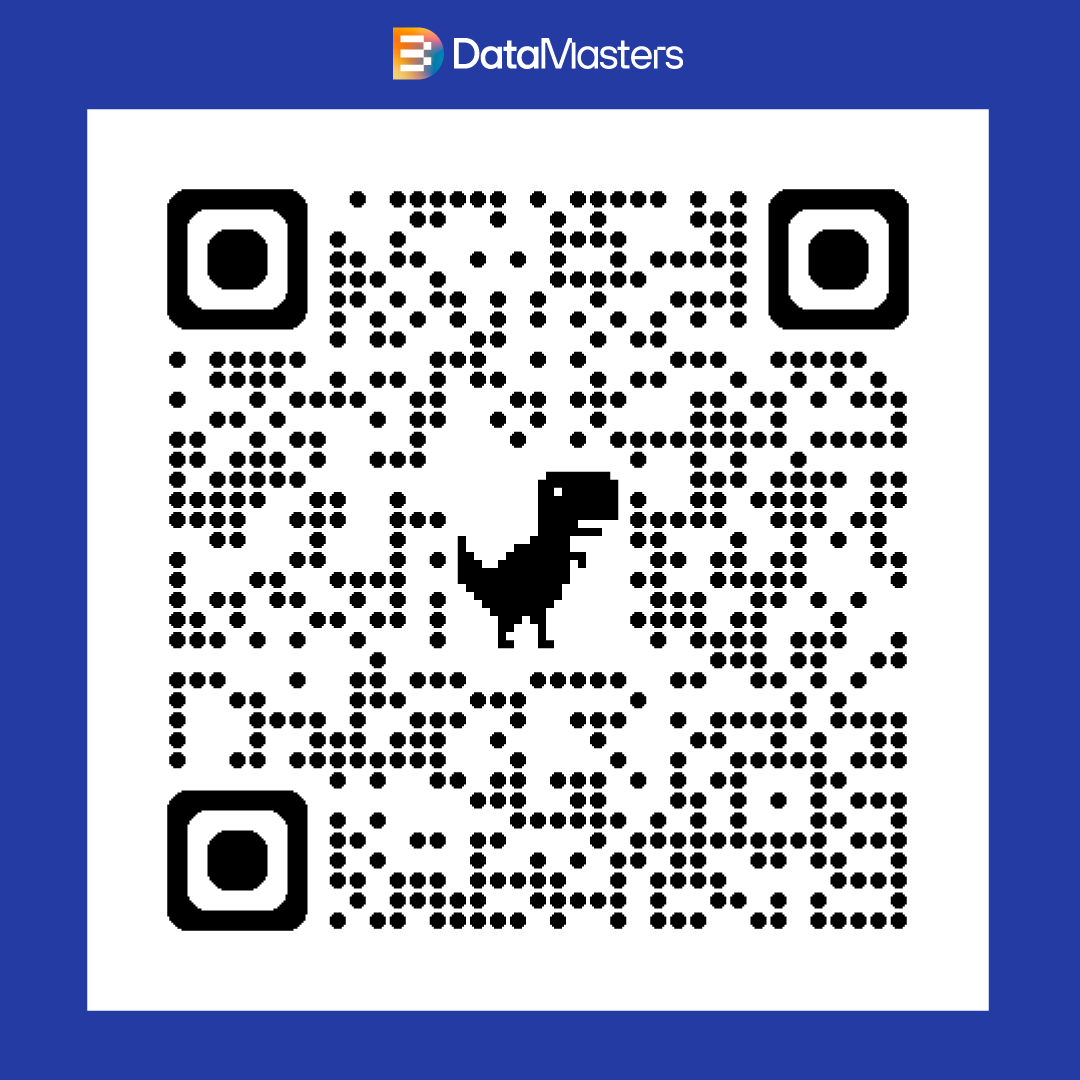

### Cosa include il Percorso AI Developer

Il percorso porta da fondamenta solide di Python e IA alla costruzione e deployment di agenti intelligenti in produzione. È pensato per chi vuole diventare un AI Developer operativo, non solo "saperne in teoria".

- **Contenuti**: Fondamenti IA, Python, Generative AI, AI Agents (n8n, OpenAI SDK, LangChain), RAG, sicurezza AI e ML-Ops, con project work mensili e certificazione finale.
- **Durata**: accesso illimitato; completamento medio in ~3 mesi con 3-5 ore/settimana.
- **Competenze acquisite**: progettazione di agenti intelligenti, integrazione API e dati, costruzione di pipeline RAG, automazione end-to-end, deployment in produzione.
- **Modalità**: ibrida - live di onboarding, lezioni on-demand, workshop guidati, project work mensili con feedback personalizzato.
- **Prezzo**: €2.680 intero; con lo sconto del 50% del workshop arrivi a una cifra significativamente sotto l'early bird standard. Pagamento in unica soluzione, 3 rate Klarna o 12 rate carta.

Il fine-tuning che abbiamo appena fatto è uno degli skill che approfondiamo nel modulo *Generative AI + AI Agents* del percorso, insieme a RAG di produzione, orchestrazione multi-agente e deployment serverless.